# Exploring Oakland Mobile Activity Data (YIHOI / geohash-7 panel)

This notebook explores `data/activity/eastbay_v1_lt10.csv`, a geohash-7-level panel of mobile-device
"stop" activity for the wider East Bay, 2019-2025, to understand **how mobile activity in Oakland has
changed over time**, and to summarize those trajectories for the commercial corridor geographies we
currently have on hand.

**Long-term project goal:** eventually link activity trajectories (this notebook) to longitudinal
business data (openings, closures, sector composition) to distinguish *activity resurgence* from
*business resurgence*. This notebook only builds the activity side of that picture.

The notebook is organized around five outputs:

1. Data-quality and temporal-comparability assessment
2. Geohash-7 activity trajectories
3. Trajectory / resurgence classification
4. Corridor-level activity profiles
5. A conceptual framework for eventually linking activity to business openings/closures

Two corridor geographies are used for context, **not treated as a complete map of Oakland's commercial
corridors**:

* `data/corridors/OAK_BIDs/OAK_BIDs.shp` — Business Improvement Districts
* `data/corridors/Policy_Polygons/Policy_Polygons.shp` — assorted policy/feasibility study polygons

No figures, tables, or intermediate files are written to disk — everything lives in this notebook.

In [1]:
import warnings

import geohash as gh
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, TwoSlopeNorm
from shapely.geometry import box
from tqdm.notebook import tqdm

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore")

In [2]:
# ---- paths (relative to analysis/activity/) ----
ACTIVITY_PATH = "../../data/activity/eastbay_v1_lt10.csv"
BID_PATH = "../../data/corridors/OAK_BIDs/OAK_BIDs.shp"
PP_PATH = "../../data/corridors/Policy_Polygons/Policy_Polygons.shp"

# ---- years represented / expected ----
YEARS = list(range(2019, 2026))
YEAR_PAIRS = list(zip(YEARS[:-1], YEARS[1:]))  # consecutive year-over-year pairs

# ---- Oakland geographic extent used to subset the wider East Bay file ----
# The raw file ("eastbay_v1") covers far more than Oakland (Section 1 shows this explicitly).
# This bounding box is the same Oakland extent used in the prior business-license/DataAxle
# exploration notebook, chosen to comfortably contain the city and the corridor shapefiles below.
OAK_LAT_RANGE = (37.695, 37.86)
OAK_LON_RANGE = (-122.355, -122.105)

# ---- CRS ----
GEO_CRS = "EPSG:4326"       # geohash decoding / lat-lon
LOCAL_CRS = "EPSG:26910"    # NAD83 UTM zone 10N (meters) - used only where projected area/length matters

# ---- primary activity measures (spec: focus on proportional, ALL-time-of-day measures) ----
PRIMARY_STOPS_COL = "PROP_STOPS_ALL"
PRIMARY_UNIQUE_COL = "PROP_UNIQUE_ALL"
RAW_STOPS_COL = "NUM_STOPS_ALL"
RAW_UNIQUE_COL = "NUM_UNIQUE_ALL"

# time-of-day / subset suffixes present in the file, beyond ALL
SECONDARY_SUFFIXES = ["95", "EVE", "WKD", "WKE"]

# ---- pandemic window used to define the "pandemic low" (deliberately excludes 2023 - see Section 3) ----
PANDEMIC_WINDOW_YEARS = [2020, 2021, 2022]

# ---- trajectory-classification parameters ----
# These are *methodology* choices (which quantile of the empirical distribution defines each
# threshold), not the resulting numeric thresholds themselves - the actual threshold values are
# computed from the data in Section 10 and printed there so the rule is fully transparent.
ACTIVE_2019_QUANTILE = 0.50   # "meaningful 2019 baseline" = at/above the median 2019 share
DECLINE_QUANTILE = 0.25       # "meaningful pandemic decline" = bottom quartile of (low - 2019)
RECOVERY_QUANTILE = 0.60      # "substantial recovery" = top 40% of (2025 - low)
GROWTH_QUANTILE = 0.75        # "meaningful long-term growth" = top quartile of (2025 - 2019)
LT_DECLINE_QUANTILE = 0.15    # "meaningful long-term decline" = bottom 15% of (2025 - 2019)
NEAR_BAND_QUANTILE = 0.40     # "near 2019" band = +/- this quantile of |2025 - 2019|
MOMENTUM_QUANTILE = 0.25      # "weakening" recent momentum = bottom quartile of (endpoint - prior year)

RNG_SEED = 42

## 1. Load and inspect the activity data

We start by loading the raw file exactly as delivered and inspecting its shape, columns, dtypes,
missingness, and coverage - without assuming anything about what the columns mean beyond what the
file itself shows us.

In [3]:
act_raw = pd.read_csv(ACTIVITY_PATH)
print("shape:", act_raw.shape)
act_raw.head()

shape: (13299, 22)


,YEAR,GEOHASH7,NUM_STOPS_ALL,PROP_STOPS_ALL,NUM_STOPS_95,PROP_STOPS_95,NUM_STOPS_EVE,PROP_STOPS_EVE,NUM_STOPS_WKD,PROP_STOPS_WKD,NUM_STOPS_WKE,PROP_STOPS_WKE,NUM_UNIQUE_ALL,PROP_UNIQUE_ALL,NUM_UNIQUE_95,PROP_UNIQUE_95,NUM_UNIQUE_EVE,PROP_UNIQUE_EVE,NUM_UNIQUE_WKD,PROP_UNIQUE_WKD,NUM_UNIQUE_WKE,PROP_UNIQUE_WKE
0,2020,9q9r8xy,<10,0.000001,<10,0.000000,<10,0.0,<10,0.000000,<10,0.000001,<10,0.000004,<10,0.000000,<10,0.0,<10,0.000000,<10,0.000004
1,2020,9qc05ym,<10,0.000001,<10,0.000001,<10,0.0,<10,0.000001,<10,0.000000,<10,0.000004,<10,0.000004,<10,0.0,<10,0.000004,<10,0.000000
2,2020,9q9mjpb,<10,0.000001,<10,0.000001,<10,0.0,<10,0.000001,<10,0.000000,<10,0.000004,<10,0.000004,<10,0.0,<10,0.000004,<10,0.000000
3,2020,9q9rb18,<10,0.000001,<10,0.000001,<10,0.0,<10,0.000001,<10,0.000000,<10,0.000004,<10,0.000004,<10,0.0,<10,0.000004,<10,0.000000
4,2020,9q9x1b1,<10,0.000001,<10,0.000001,<10,0.0,<10,0.000001,<10,0.000000,<10,0.000004,<10,0.000004,<10,0.0,<10,0.000004,<10,0.000000


In [4]:
print("dtypes:")
print(act_raw.dtypes)
print()
print("missingness (fraction of rows null per column):")
print(act_raw.isna().mean())

dtypes:
YEAR                 int64
GEOHASH7            object
NUM_STOPS_ALL       object
PROP_STOPS_ALL     float64
NUM_STOPS_95        object
PROP_STOPS_95      float64
NUM_STOPS_EVE       object
PROP_STOPS_EVE     float64
NUM_STOPS_WKD       object
PROP_STOPS_WKD     float64
NUM_STOPS_WKE       object
PROP_STOPS_WKE     float64
NUM_UNIQUE_ALL      object
PROP_UNIQUE_ALL    float64
NUM_UNIQUE_95       object
PROP_UNIQUE_95     float64
NUM_UNIQUE_EVE      object
PROP_UNIQUE_EVE    float64
NUM_UNIQUE_WKD      object
PROP_UNIQUE_WKD    float64
NUM_UNIQUE_WKE      object
PROP_UNIQUE_WKE    float64
dtype: object

missingness (fraction of rows null per column):
YEAR               0.0
GEOHASH7           0.0
NUM_STOPS_ALL      0.0
PROP_STOPS_ALL     0.0
NUM_STOPS_95       0.0
PROP_STOPS_95      0.0
NUM_STOPS_EVE      0.0
PROP_STOPS_EVE     0.0
NUM_STOPS_WKD      0.0
PROP_STOPS_WKD     0.0
NUM_STOPS_WKE      0.0
PROP_STOPS_WKE     0.0
NUM_UNIQUE_ALL     0.0
PROP_UNIQUE_ALL    0.0
NUM_UNIQUE_95

In [5]:
print("years represented:", sorted(act_raw["YEAR"].unique()))
print("n unique GEOHASH7 cells (entire file, all years):", act_raw["GEOHASH7"].nunique())
print()
print("records per year:")
print(act_raw["YEAR"].value_counts().sort_index())
print()
n_dupe_geohash_year = act_raw.duplicated(subset=["YEAR", "GEOHASH7"]).sum()
print("duplicate (YEAR, GEOHASH7) rows:", n_dupe_geohash_year, "-> each geohash-year appears at most once:", n_dupe_geohash_year == 0)

years represented: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
n unique GEOHASH7 cells (entire file, all years): 2621

records per year:
YEAR
2019    1869
2020    1970
2021    1946
2022    1957
2023    1148
2024    2167
2025    2242
Name: count, dtype: int64

duplicate (YEAR, GEOHASH7) rows: 0 -> each geohash-year appears at most once: True


**Geographic footprint.** The file is named `eastbay_v1`, and the geohash-7 codes themselves decode to
lat/lon - so before going further we check how much of the file actually falls within Oakland.

In [6]:
all_geohashes = act_raw["GEOHASH7"].drop_duplicates()
decoded = all_geohashes.apply(gh.decode)
decoded_lat = decoded.apply(lambda t: t[0])
decoded_lon = decoded.apply(lambda t: t[1])

print("full-file footprint: lat [{:.3f}, {:.3f}], lon [{:.3f}, {:.3f}]".format(
    decoded_lat.min(), decoded_lat.max(), decoded_lon.min(), decoded_lon.max()))

in_oakland = decoded_lat.between(*OAK_LAT_RANGE) & decoded_lon.between(*OAK_LON_RANGE)
oak_geohashes = set(all_geohashes[in_oakland])
print(f"geohash-7 cells within the Oakland extent: {len(oak_geohashes):,} / {len(all_geohashes):,} "
      f"({len(oak_geohashes) / len(all_geohashes):.1%})")

full-file footprint: lat [37.464, 38.094], lon [-122.431, -121.501]
geohash-7 cells within the Oakland extent: 310 / 2,621 (11.8%)


Only a small share of the geohash-7 cells in this file fall inside Oakland's extent - the rest of the
file covers the broader East Bay (Fremont, Concord, Livermore-area cells, etc. are all in the same
`eastbay_v1` export). **This notebook's job is specifically about Oakland**, so from Section 2 onward we
work with an Oakland-only subset (`act`), while `act_raw` above is kept untouched as the original import.

In [7]:
act = act_raw[act_raw["GEOHASH7"].isin(oak_geohashes)].copy()
print(f"Oakland-filtered shape: {act.shape} (from {act_raw.shape[0]:,} raw rows)")
print()
print("records per year, Oakland only:")
print(act["YEAR"].value_counts().sort_index())

Oakland-filtered shape: (1756, 22) (from 13,299 raw rows)

records per year, Oakland only:
YEAR
2019    247
2020    246
2021    257
2022    255
2023    193
2024    277
2025    281
Name: count, dtype: int64


**How suppression is represented.** Raw counts below a small-count privacy threshold are masked as the
string `"<10"` rather than a number - so the raw `NUM_*` columns are stored as text, not numeric, and
mix real integers with the literal string `"<10"`. The proportional `PROP_*` columns, by contrast, are
always numeric and never missing, even on suppressed rows (see the sample below) - suppression hides the
*raw count*, not the *share*.

In [8]:
act[[c for c in act.columns if c.startswith("NUM_") or c.startswith("PROP_")]].head(8)

,NUM_STOPS_ALL,PROP_STOPS_ALL,NUM_STOPS_95,PROP_STOPS_95,NUM_STOPS_EVE,PROP_STOPS_EVE,NUM_STOPS_WKD,PROP_STOPS_WKD,NUM_STOPS_WKE,PROP_STOPS_WKE,NUM_UNIQUE_ALL,PROP_UNIQUE_ALL,NUM_UNIQUE_95,PROP_UNIQUE_95,NUM_UNIQUE_EVE,PROP_UNIQUE_EVE,NUM_UNIQUE_WKD,PROP_UNIQUE_WKD,NUM_UNIQUE_WKE,PROP_UNIQUE_WKE
25,408,0.000253,153,0.000095,97,0.000060,269,0.000167,139,0.000086,158,0.000575,62,0.000226,58,0.000211,106,0.000386,74,0.000269
36,456,0.000283,189,0.000117,167,0.000104,340,0.000211,116,0.000072,160,0.000582,80,0.000291,69,0.000251,125,0.000455,58,0.000211
37,236,0.000146,71,0.000044,91,0.000056,157,0.000097,79,0.000049,92,0.000335,41,0.000149,44,0.000160,66,0.000240,45,0.000164
38,203,0.000126,58,0.000036,80,0.000050,120,0.000074,83,0.000051,66,0.000240,27,0.000098,31,0.000113,46,0.000167,36,0.000131
44,3050,0.001891,1254,0.000778,1030,0.000639,2142,0.001328,908,0.000563,1022,0.003718,517,0.001881,453,0.001648,765,0.002783,452,0.001644
45,6455,0.004003,2546,0.001579,2360,0.001463,4648,0.002882,1807,0.001120,101,0.000367,70,0.000255,51,0.000186,88,0.000320,55,0.000200
109,2653,0.001645,1226,0.000760,709,0.000440,2182,0.001353,471,0.000292,885,0.003219,561,0.002041,111,0.000404,701,0.002550,261,0.000949
118,2155,0.001336,1021,0.000633,439,0.000272,1796,0.001114,359,0.000223,781,0.002841,397,0.001444,335,0.001219,594,0.002161,265,0.000964


In [9]:
print("Is NUM_STOPS_ALL ever a plain number vs the literal '<10'? sample of distinct raw values:")
print(act["NUM_STOPS_ALL"].astype(str).str.replace(r"^\d+$", "<numeric>", regex=True).value_counts().head())
print()
print("Any missing PROP_STOPS_ALL / PROP_UNIQUE_ALL rows?",
      act["PROP_STOPS_ALL"].isna().sum(), "/", act["PROP_UNIQUE_ALL"].isna().sum())

Is NUM_STOPS_ALL ever a plain number vs the literal '<10'? sample of distinct raw values:
NUM_STOPS_ALL
<numeric>    1418
<10           338
Name: count, dtype: int64

Any missing PROP_STOPS_ALL / PROP_UNIQUE_ALL rows? 0 / 0


**Stops vs. unique devices - two different concepts, used deliberately throughout this notebook:**

* **Stops (`NUM_STOPS_*` / `PROP_STOPS_*`):** the total count of observed stop events. A single device
  that visits a geohash five times in a period contributes five stops. This measures the *volume* of
  observed activity, including repeat visits.
* **Unique devices (`NUM_UNIQUE_*` / `PROP_UNIQUE_*`):** the count of *distinct* devices observed in a
  geohash/period, regardless of how many times each one stopped there. This measures the *breadth* of
  observed foot traffic.

A geohash can gain more stops without gaining more unique devices (existing visitors returning more
often), or vice versa (more distinct visitors, each stopping only once). We keep these as two
complementary measures throughout rather than collapsing them into one number.

**Takeaway - Section 1.** The raw file is a geohash-7 x year panel (one row per geohash-year, no
duplicates), spanning 2019-2025 across the wider East Bay - only a small fraction of which is Oakland.
Raw stop/unique counts are suppressed below 10 (`"<10"`, stored as text), but the proportional measures
are always populated, including on suppressed rows. From here on we work with `act`, the Oakland-only
subset, and keep `PROP_STOPS_ALL` (volume) and `PROP_UNIQUE_ALL` (breadth) conceptually distinct.

## 2. Establish the primary measures

The core longitudinal analysis in this notebook focuses on **`PROP_STOPS_ALL`** (primary measure of
activity intensity/trajectory) and **`PROP_UNIQUE_ALL`** (complementary robustness measure), for the
`ALL` time-of-day category. The proportional measures are preferable for comparing across years because
the *number of devices the provider observes at all* can vary year to year for reasons that have nothing
to do with Oakland - a raw stop count increase could just mean the vendor's panel grew.

First we check, empirically, whether the proportional measures actually sum to ~1 within each year -
this is what would justify reading them as "this geohash's share of all observed activity that year."
We check this on the **full, un-filtered file** (`act_raw`), since the shares are presumably defined
over the entire East Bay export, not just the Oakland subset.

In [10]:
prop_sums = act_raw.groupby("YEAR")[["PROP_STOPS_ALL", "PROP_UNIQUE_ALL"]].sum()
prop_sums.columns = ["sum_PROP_STOPS_ALL", "sum_PROP_UNIQUE_ALL"]
prop_sums

,sum_PROP_STOPS_ALL,sum_PROP_UNIQUE_ALL
YEAR,,
2019,0.999917,1.000062
2020,1.000062,1.000065
2021,1.000122,1.000060
2022,0.999942,1.000050
2023,1.000100,0.999974
2024,1.000043,1.000082
2025,0.999940,1.000063


**Takeaway.** Within every year, both proportional measures sum to ~1.000 (within rounding) across the
full East Bay file. This confirms they can be read as *"this geohash's share of that year's total
observed activity, East-Bay-wide."* It does **not** mean absolute visit volumes are comparable across
years - the denominator (total observed activity, and the underlying device panel size) can itself
change year to year, so a geohash's *share* can rise even if its *absolute* activity is flat or falling,
and vice versa. We build the longitudinal analysis on shares, not raw counts, for exactly this reason.

One consequence worth flagging: because these are *shares of the whole East Bay*, and we are about to
restrict to the Oakland subset, **the Oakland `PROP_STOPS_ALL` values will not themselves sum to 1** -
they will sum to Oakland's share of total East Bay activity for that year. We check that below too, since
it is itself a useful (if secondary) coverage statistic.

In [11]:
oak_prop_sums = act.groupby("YEAR")[["PROP_STOPS_ALL", "PROP_UNIQUE_ALL"]].sum()
oak_prop_sums.columns = ["oakland_share_of_stops", "oakland_share_of_unique"]
oak_prop_sums

,oakland_share_of_stops,oakland_share_of_unique
YEAR,,
2019,0.155727,0.218756
2020,0.146978,0.197648
2021,0.142545,0.199373
2022,0.147060,0.202308
2023,0.240274,0.276890
2024,0.203401,0.243451
2025,0.200042,0.243760


We also keep the raw `NUM_STOPS_ALL` / `NUM_UNIQUE_ALL` columns around (converted to numeric, with `"<10"`
mapped to missing) purely to understand suppression and rough scale - they are **not** used to build the
main longitudinal comparisons.

In [12]:
for raw_col, clean_col, flag_col in [
    ("NUM_STOPS_ALL", "num_stops_all_clean", "stops_all_suppressed"),
    ("NUM_UNIQUE_ALL", "num_unique_all_clean", "unique_all_suppressed"),
]:
    act[flag_col] = act[raw_col].astype(str).str.strip().eq("<10")
    act[clean_col] = pd.to_numeric(act[raw_col], errors="coerce")

act[["NUM_STOPS_ALL", "num_stops_all_clean", "stops_all_suppressed",
     "NUM_UNIQUE_ALL", "num_unique_all_clean", "unique_all_suppressed"]].head(6)

,NUM_STOPS_ALL,num_stops_all_clean,stops_all_suppressed,NUM_UNIQUE_ALL,num_unique_all_clean,unique_all_suppressed
25,408,408.0,False,158,158.0,False
36,456,456.0,False,160,160.0,False
37,236,236.0,False,92,92.0,False
38,203,203.0,False,66,66.0,False
44,3050,3050.0,False,1022,1022.0,False
45,6455,6455.0,False,101,101.0,False


**Takeaway - Section 2.** Proportional measures sum to ~1 East-Bay-wide each year, so they are valid
shares for longitudinal comparison; Oakland's own share of that total activity is a useful secondary
signal but is not itself the primary metric. `PROP_STOPS_ALL` and `PROP_UNIQUE_ALL` are the two measures
carried through the rest of the notebook; raw counts are retained (with suppression flagged) for context
only.

## 3. Data-quality and temporal-comparability assessment

Before trusting any year-over-year comparison, we need to know whether the years are actually comparable:
how many geohashes are observed each year, how much of the raw data is suppressed, whether the same
geohashes persist across years, and whether any single year looks structurally different from its
neighbors.

In [13]:
def year_quality_row(g):
    return pd.Series({
        "n_geohash": g["GEOHASH7"].nunique(),
        "pct_stops_suppressed": (g["NUM_STOPS_ALL"].astype(str).str.strip() == "<10").mean(),
        "pct_unique_suppressed": (g["NUM_UNIQUE_ALL"].astype(str).str.strip() == "<10").mean(),
        "sum_PROP_STOPS_ALL": g["PROP_STOPS_ALL"].sum(),
        "mean_PROP_STOPS_ALL": g["PROP_STOPS_ALL"].mean(),
        "median_PROP_STOPS_ALL": g["PROP_STOPS_ALL"].median(),
        "mean_num_stops_clean": pd.to_numeric(g["NUM_STOPS_ALL"], errors="coerce").mean(),
    })

year_quality = act.groupby("YEAR").apply(year_quality_row)
year_quality

,n_geohash,pct_stops_suppressed,pct_unique_suppressed,sum_PROP_STOPS_ALL,mean_PROP_STOPS_ALL,median_PROP_STOPS_ALL,mean_num_stops_clean
YEAR,,,,,,,
2019,247.0,0.149798,0.174089,0.155727,0.000630,0.000168,1655.390476
2020,246.0,0.162602,0.186992,0.146978,0.000597,0.000174,1150.004854
2021,257.0,0.175097,0.194553,0.142545,0.000555,0.000156,1269.797170
2022,255.0,0.160784,0.172549,0.147060,0.000577,0.000126,1605.504673
2023,193.0,0.388601,0.632124,0.240274,0.001245,0.000281,113.915254
2024,277.0,0.173285,0.173285,0.203401,0.000734,0.000253,3494.768559
2025,281.0,0.185053,0.188612,0.200042,0.000712,0.000240,4345.384279


Note: `PROP_STOPS_ALL` / `PROP_UNIQUE_ALL` are never missing on rows that exist (Section 1), so
"percent with usable proportional measure" is trivially 100% *among observed rows* - the real coverage
question is which geohashes have a row at all in a given year, which is exactly `n_geohash` above plus
the panel-continuity analysis below.

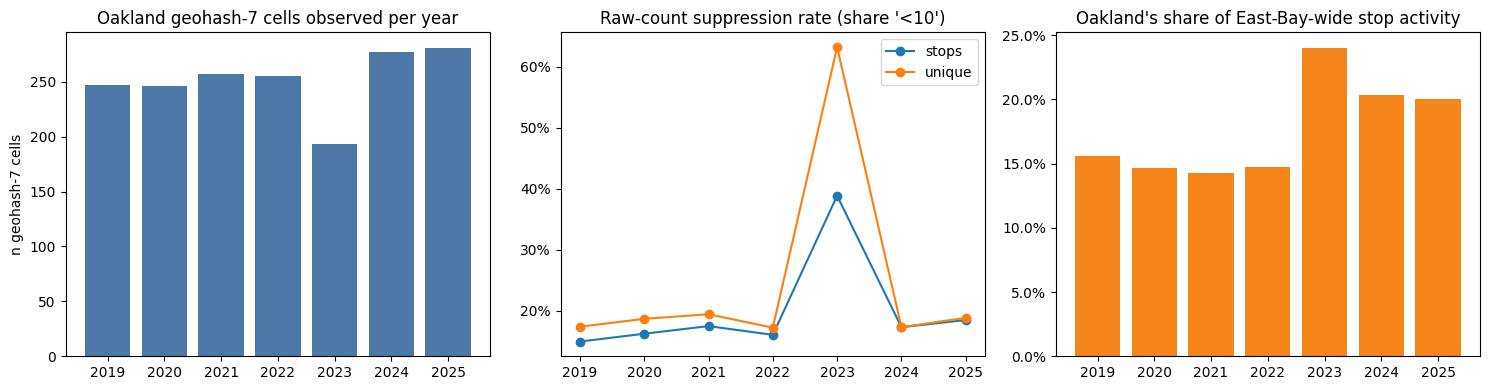

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(year_quality.index.astype(str), year_quality["n_geohash"], color="#4C78A8")
axes[0].set_title("Oakland geohash-7 cells observed per year")
axes[0].set_ylabel("n geohash-7 cells")

axes[1].plot(year_quality.index, year_quality["pct_stops_suppressed"], marker="o", label="stops")
axes[1].plot(year_quality.index, year_quality["pct_unique_suppressed"], marker="o", label="unique")
axes[1].set_title("Raw-count suppression rate (share '<10')")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()

axes[2].bar(year_quality.index.astype(str), year_quality["sum_PROP_STOPS_ALL"], color="#F58518")
axes[2].set_title("Oakland's share of East-Bay-wide stop activity")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

**Takeaway.** Both the geohash count and the suppression rate move together in a way that flags one year
immediately: **2023** has noticeably fewer geohash-7 cells observed and a much higher suppression rate
than every surrounding year, for both stops and unique devices. We dig into this specifically below.

### Geohash panel continuity

How persistent is the same set of geohash-7 cells across years? A geohash observed in only one year tells
us much less about a "trajectory" than one observed continuously.

In [15]:
years_observed = act.groupby("GEOHASH7")["YEAR"].nunique()
continuity_counts = years_observed.value_counts().sort_index()
continuity_counts.index.name = "n_years_observed"
print(continuity_counts)
print()
print(f"observed in all {len(YEARS)} years: {(years_observed == len(YEARS)).sum():,} / {len(years_observed):,} "
      f"({(years_observed == len(YEARS)).mean():.1%})")
print(f"observed in only 1 year: {(years_observed == 1).sum():,} ({(years_observed == 1).mean():.1%})")

n_years_observed
1     20
2     25
3     18
4     11
5     14
6     36
7    186
Name: count, dtype: int64

observed in all 7 years: 186 / 310 (60.0%)
observed in only 1 year: 20 (6.5%)


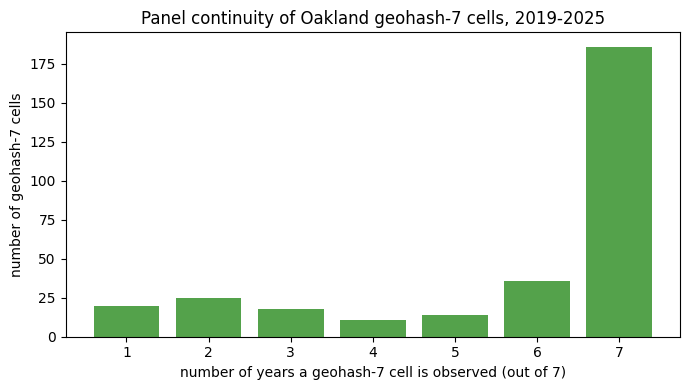

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(continuity_counts.index.astype(str), continuity_counts.values, color="#54A24B")
ax.set_xlabel("number of years a geohash-7 cell is observed (out of 7)")
ax.set_ylabel("number of geohash-7 cells")
ax.set_title("Panel continuity of Oakland geohash-7 cells, 2019-2025")
plt.tight_layout()
plt.show()

In [17]:
# year-to-year retention: of the geohashes observed in year t, what share are also observed in year t+1?
oak_geohash_by_year = {y: set(act.loc[act["YEAR"] == y, "GEOHASH7"]) for y in YEARS}
retention_rows = []
for y0, y1 in YEAR_PAIRS:
    g0, g1 = oak_geohash_by_year[y0], oak_geohash_by_year[y1]
    retention_rows.append({
        "from_year": y0, "to_year": y1,
        "n_in_from_year": len(g0),
        "n_retained": len(g0 & g1),
        "pct_retained": len(g0 & g1) / len(g0) if g0 else np.nan,
        "n_new_in_to_year": len(g1 - g0),
    })
retention = pd.DataFrame(retention_rows)
retention

,from_year,to_year,n_in_from_year,n_retained,pct_retained,n_new_in_to_year
0,2019,2020,247,230,0.931174,16
1,2020,2021,246,234,0.951220,23
2,2021,2022,257,235,0.914397,20
3,2022,2023,255,189,0.741176,4
4,2023,2024,193,188,0.974093,89
5,2024,2025,277,266,0.960289,15


### 2023 diagnostic

2023 stood out above on both geohash count and suppression rate. We treat 2023 with explicit caution and
check whether this looks like a coverage/methodology artifact rather than a real activity change.

In [18]:
gh_2022 = oak_geohash_by_year[2022]
gh_2023 = oak_geohash_by_year[2023]
gh_2024 = oak_geohash_by_year[2024]

print(f"n geohashes: 2022={len(gh_2022)}, 2023={len(gh_2023)}, 2024={len(gh_2024)}")
present_both_sides = gh_2022 & gh_2024
missing_2023 = present_both_sides - gh_2023
print(f"present in both 2022 and 2024: {len(present_both_sides)}")
print(f"...of those, ALSO missing from 2023: {len(missing_2023)} ({len(missing_2023) / len(present_both_sides):.1%})")

n geohashes: 2022=255, 2023=193, 2024=277
present in both 2022 and 2024: 245
...of those, ALSO missing from 2023: 58 (23.7%)


In [19]:
# are the cells missing from 2023 disproportionately low-activity cells in the surrounding years?
sub = act[(act["YEAR"] == 2022) & (act["GEOHASH7"].isin(present_both_sides))].copy()
sub["missing_in_2023"] = sub["GEOHASH7"].isin(missing_2023)
print("2022 PROP_STOPS_ALL, split by whether the cell is missing from 2023:")
sub.groupby("missing_in_2023")["PROP_STOPS_ALL"].describe()

2022 PROP_STOPS_ALL, split by whether the cell is missing from 2023:


,count,mean,std,min,25%,50%,75%,max
missing_in_2023,,,,,,,,
False,187.0,0.000780,0.001172,0.000001,8.450000e-05,0.000271,0.000947,0.005951
True,58.0,0.000022,0.000067,0.000000,2.500000e-07,0.000003,0.000014,0.000489


The cells that drop out of the panel in 2023 have a **much lower median 2022 activity share** than the
cells that persist into 2023 - i.e. 2023's smaller footprint is concentrated in low-activity cells,
consistent with a coverage/reporting-threshold effect rather than those specific locations genuinely
losing all their activity for one year and then reappearing.

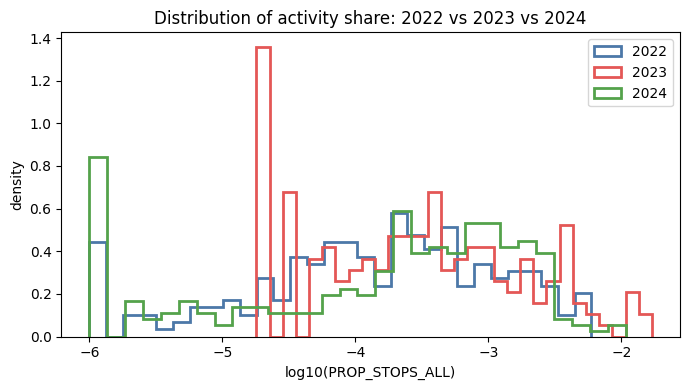

In [20]:
# does the *distribution* of activity among cells that ARE reported in 2023 look unusual?
fig, ax = plt.subplots(figsize=(7, 4))
for y, color in zip([2022, 2023, 2024], ["#4C78A8", "#E45756", "#54A24B"]):
    vals = act.loc[act["YEAR"] == y, "PROP_STOPS_ALL"]
    vals = vals[vals > 0]  # drop true zeros - log10 is undefined there
    ax.hist(np.log10(vals), bins=30, histtype="step", linewidth=2, label=str(y), color=color, density=True)
ax.set_xlabel("log10(PROP_STOPS_ALL)")
ax.set_ylabel("density")
ax.set_title("Distribution of activity share: 2022 vs 2023 vs 2024")
ax.legend()
plt.tight_layout()
plt.show()

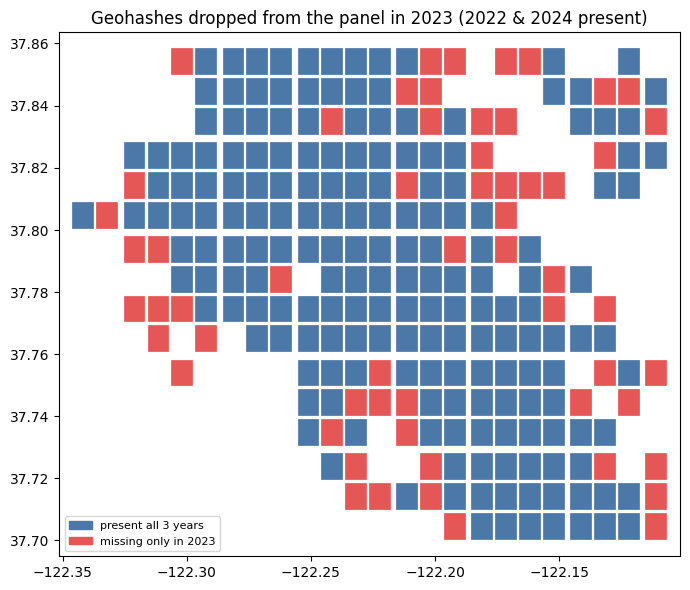

In [21]:
# do the geohashes present in 2022 & 2024 but absent in 2023 cluster geographically?
missing_latlon = pd.DataFrame(
    [gh.decode(g) for g in missing_2023], columns=["lat", "lon"], index=list(missing_2023)
)
present_latlon = pd.DataFrame(
    [gh.decode(g) for g in (present_both_sides - missing_2023)], columns=["lat", "lon"]
)

# Draw each geohash as a small rectangle rather than a point: a true geohash-7 cell (~150m) would be
# imperceptible at this map scale, so size each square to the empirical spacing between sampled
# cells (same "approximate size, not true scale" approach used for the maps from Section 5 onward).
all_lat = pd.concat([missing_latlon["lat"], present_latlon["lat"]])
all_lon = pd.concat([missing_latlon["lon"], present_latlon["lon"]])
step = np.median(np.concatenate([np.diff(np.sort(all_lat.unique())), np.diff(np.sort(all_lon.unique()))]))
half = step * 0.45  # slight gap between neighboring squares so the grid stays legible


def cell_patches(df, color):
    return [
        mpatches.Rectangle((lo - half, la - half), 2 * half, 2 * half, facecolor=color, edgecolor="white", linewidth=0.2)
        for la, lo in zip(df["lat"], df["lon"])
    ]


fig, ax = plt.subplots(figsize=(7, 7))
for patch in cell_patches(present_latlon, "#4C78A8"):
    ax.add_patch(patch)
for patch in cell_patches(missing_latlon, "#E45756"):
    ax.add_patch(patch)
ax.set_xlim(all_lon.min() - step, all_lon.max() + step)
ax.set_ylim(all_lat.min() - step, all_lat.max() + step)
ax.set_aspect(1.25)
ax.set_title("Geohashes dropped from the panel in 2023 (2022 & 2024 present)")
legend_handles = [
    mpatches.Patch(color="#4C78A8", label="present all 3 years"),
    mpatches.Patch(color="#E45756", label="missing only in 2023"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()


**Takeaway - Section 3.** 2019, 2020, 2021, 2022, 2024, and 2025 look broadly comparable in geohash
count and suppression rate. **2023 does not**: it has ~30-40% fewer Oakland geohash cells, roughly
double the raw-stops suppression rate, and more than triple the raw-unique-device suppression rate of
neighboring years, and the cells that drop out are systematically the
lower-activity ones rather than a random or geographically clustered subset - consistent with a coverage
or reporting-threshold difference in how 2023 was compiled, not a real one-year collapse in Oakland
mobile activity. We continue to display 2023 year-by-year throughout this notebook (per the brief), but
we flag every year-over-year comparison that touches 2023, and we deliberately keep the pandemic-low and
resurgence definitions (Sections 7-11) from depending on 2023.

## 4. Construct geohash-7 geometries

We work entirely at geohash-7 precision (no coarsening). Each geohash string decodes to a bounding box;
we build that box as a polygon, take its centroid, and attach the activity measures to make a proper
GeoDataFrame.

In [22]:
def geohash_to_polygon(geohash7):
    b = gh.bbox(geohash7)
    return box(b["w"], b["s"], b["e"], b["n"])


oak_geohash_list = sorted(oak_geohashes)
oak_geom = gpd.GeoDataFrame(
    {"geohash7": oak_geohash_list},
    geometry=[geohash_to_polygon(g) for g in oak_geohash_list],
    crs=GEO_CRS,
)
oak_geom["centroid"] = oak_geom.geometry.centroid
oak_geom = oak_geom.set_index("geohash7")

print(f"built {len(oak_geom):,} geohash-7 polygons")
example_cell_m2 = oak_geom.geometry.to_crs(LOCAL_CRS).iloc[0].area
print(f"example cell area: ~{example_cell_m2:,.0f} m^2 (geohash-7 cells are roughly uniform in size)")

# The dataset only samples ~1 in 7 possible geohash-7 cells along each axis, so the true geohash-7
# box (~150m) renders as an imperceptible dot at Oakland-map scale. For the maps below, build a
# "visual" square per geohash sized to the empirical spacing between neighboring sampled cells
# (not the true, much smaller, geohash-7 footprint) -- this keeps one rectangle per geohash, just
# drawn at a size a reader can actually perceive, rather than as a swarm of points.
centroid_lats = np.sort(oak_geom["centroid"].y.unique())
centroid_lons = np.sort(oak_geom["centroid"].x.unique())
grid_step_deg = np.median(np.concatenate([np.diff(centroid_lats), np.diff(centroid_lons)]))
print(f"empirical sampling grid step: ~{grid_step_deg:.5f} deg (~{grid_step_deg * 111_000:,.0f} m)")

half = grid_step_deg * 0.45  # slight gap between neighboring squares so the grid stays legible
oak_geom["vis_geometry"] = [
    box(x - half, y - half, x + half, y + half)
    for x, y in zip(oak_geom["centroid"].x, oak_geom["centroid"].y)
]
oak_geom.head()


built 310 geohash-7 polygons
example cell area: ~18,416 m^2 (geohash-7 cells are roughly uniform in size)
empirical sampling grid step: ~0.00961 deg (~1,067 m)


,geometry,centroid,vis_geometry
geohash7,,,
9q8zpvd,"POLYGON ((-122.35062 37.82318, -122.35062 37.8...",POINT (-122.35130 37.82387),POLYGON ((-122.34697723388672 37.8195419311523...
9q8zpzd,"POLYGON ((-122.35062 37.83417, -122.35062 37.8...",POINT (-122.35130 37.83485),POLYGON ((-122.34697723388672 37.8305282592773...
9q8zrc6,"POLYGON ((-122.35062 37.84378, -122.35062 37.8...",POINT (-122.35130 37.84447),POLYGON ((-122.34697723388672 37.8401412963867...
9q8zrg4,"POLYGON ((-122.35062 37.85339, -122.35062 37.8...",POINT (-122.35130 37.85408),POLYGON ((-122.34697723388672 37.8497543334960...
9q9n3zg,"POLYGON ((-122.26135 37.70370, -122.26135 37.7...",POINT (-122.26204 37.70439),POLYGON ((-122.2577133178711 37.70006561279297...


In [23]:
# long-form GeoDataFrame: geohash7 x year x geometry x centroid x activity measures
act_geo = act.merge(oak_geom[["geometry", "centroid", "vis_geometry"]], left_on="GEOHASH7", right_index=True, how="left")
act_geo = gpd.GeoDataFrame(act_geo, geometry="geometry", crs=GEO_CRS)
print(act_geo.shape)
act_geo[["YEAR", "GEOHASH7", "PROP_STOPS_ALL", "PROP_UNIQUE_ALL", "geometry", "centroid"]].head()


(1756, 29)


,YEAR,GEOHASH7,PROP_STOPS_ALL,PROP_UNIQUE_ALL,geometry,centroid
25,2020,9q9p45g,0.000253,0.000575,"POLYGON ((-122.25037 37.81357, -122.25037 37.8...",POINT (-122.25105 37.81425)
36,2020,9q9ngsw,0.000283,0.000582,"POLYGON ((-122.18033 37.77374, -122.18033 37.7...",POINT (-122.18102 37.77443)
37,2020,9q9ng6y,0.000146,0.000335,"POLYGON ((-122.19131 37.76413, -122.19131 37.7...",POINT (-122.19200 37.76482)
38,2020,9q9ngqq,0.000126,0.000240,"POLYGON ((-122.19131 37.78336, -122.19131 37.7...",POINT (-122.19200 37.78404)
44,2020,9q9n7xy,0.001891,0.003718,"POLYGON ((-122.18033 37.70370, -122.18033 37.7...",POINT (-122.18102 37.70439)


**Takeaway - Section 4.** Every Oakland geohash-7 cell now has an explicit polygon and centroid,
attached to its yearly activity measures without altering the original `act` columns. This is the
geometry we use for every map and every spatial join in the rest of the notebook.

## 5. Map activity levels by year

Small-multiple maps of `PROP_STOPS_ALL` for each year, on a shared extent and a shared color scale (so
panels are visually comparable), let us see how the *geography* of activity has shifted since 2019.

shared color scale (log): vmin=1.00e-06, vmax=6.24e-03


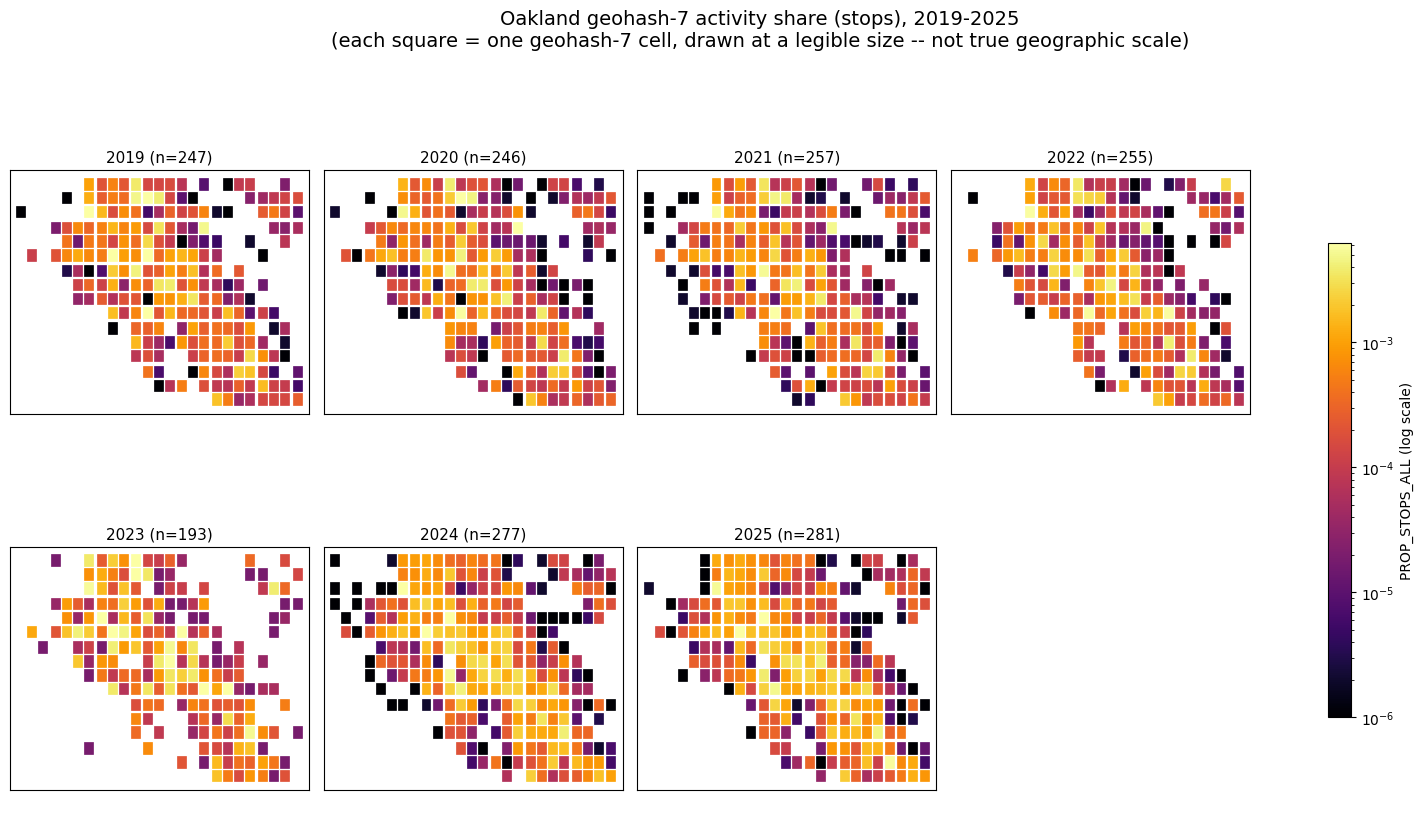

In [24]:
# shared color scale across all years: use a log scale (activity share spans orders of magnitude)
# and cap at the 99th percentile across all years so one extreme cell doesn't wash out the rest.
vmin = act.loc[act["PROP_STOPS_ALL"] > 0, "PROP_STOPS_ALL"].quantile(0.02)
vmax = act["PROP_STOPS_ALL"].quantile(0.99)
print(f"shared color scale (log): vmin={vmin:.2e}, vmax={vmax:.2e}")

# crop tightly to where geohashes actually are (plus one grid step of padding) instead of the full
# Oakland bounding box, so the legible-sized squares aren't dwarfed by empty margin
xlim = (oak_geom["centroid"].x.min() - grid_step_deg, oak_geom["centroid"].x.max() + grid_step_deg)
ylim = (oak_geom["centroid"].y.min() - grid_step_deg, oak_geom["centroid"].y.max() + grid_step_deg)

fig, axes = plt.subplots(2, 4, figsize=(20, 8.8), gridspec_kw={"wspace": 0.05, "hspace": 0.25})
axes = axes.ravel()
for i, year in enumerate(YEARS):
    ax = axes[i]
    sub = act_geo[act_geo["YEAR"] == year].set_geometry("vis_geometry")
    sub.plot(
        column="PROP_STOPS_ALL", ax=ax, cmap="inferno",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        edgecolor="white", linewidth=0.2,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect(1.25)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{year} (n={len(sub):,})", fontsize=11)
axes[-1].axis("off")

sm = plt.cm.ScalarMappable(cmap="inferno", norm=LogNorm(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, label="PROP_STOPS_ALL (log scale)")
plt.suptitle(
    "Oakland geohash-7 activity share (stops), 2019-2025\n"
    "(each square = one geohash-7 cell, drawn at a legible size -- not true geographic scale)",
    fontsize=14, y=1.03,
)
plt.show()


**Takeaway.** A persistent core of high-activity cells (Downtown/Lake Merritt/Broadway corridor and along
the I-580/I-880 commercial spine) is visible in every year - the broad geography of *where* activity
concentrates in Oakland has not been reshuffled wholesale. 2023's map is visibly sparser (fewer cells
plotted at all, consistent with the Section 3 finding), and some peripheral cells appear/disappear
between years - a reminder to focus on cells with sustained coverage for trend claims, not on any single
cell's presence/absence in one year.

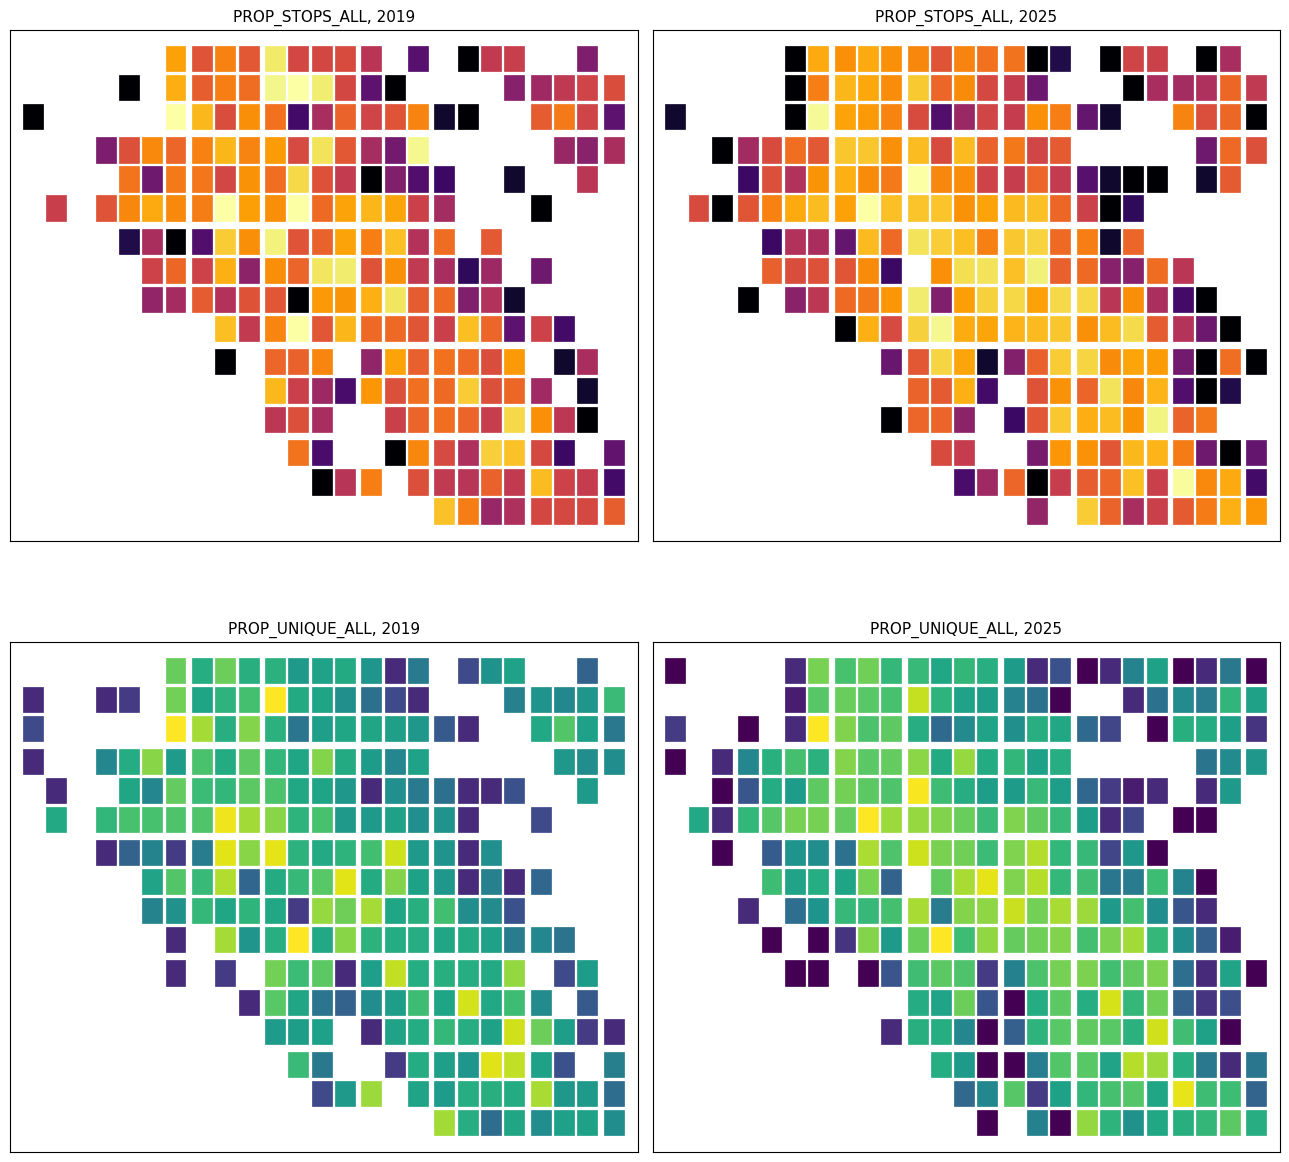

In [25]:
# robustness comparison: PROP_UNIQUE_ALL for the two endpoint years, alongside PROP_STOPS_ALL
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for col_i, year in enumerate([2019, 2025]):
    for row_i, (measure, cmap) in enumerate([("PROP_STOPS_ALL", "inferno"), ("PROP_UNIQUE_ALL", "viridis")]):
        ax = axes[row_i, col_i]
        sub = act_geo[act_geo["YEAR"] == year].set_geometry("vis_geometry")
        vmin_m = act.loc[act[measure] > 0, measure].quantile(0.02)
        vmax_m = act[measure].quantile(0.99)
        sub.plot(column=measure, ax=ax, cmap=cmap, norm=LogNorm(vmin=vmin_m, vmax=vmax_m), edgecolor="white", linewidth=0.2)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect(1.25)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{measure}, {year}", fontsize=11)
plt.tight_layout()
plt.show()


**Takeaway - Section 5.** Stops and unique-device maps show essentially the same hotspots in both 2019
and 2025 - reassuring for using either as a geographic proxy - while the overall pattern of concentration
around the same core commercial areas persists across the full period.

## 6. Build a wide geohash-year analytical table

For longitudinal comparisons it's easier to work with one row per geohash and one column per year. We
build wide tables for both primary measures and keep the long-form `act` / `act_geo` around for plotting
and mapping.

In [26]:
wide_stops = act.pivot(index="GEOHASH7", columns="YEAR", values="PROP_STOPS_ALL")
wide_unique = act.pivot(index="GEOHASH7", columns="YEAR", values="PROP_UNIQUE_ALL")
print("wide_stops shape:", wide_stops.shape)
wide_stops.head()

wide_stops shape: (310, 7)


YEAR,2019,2020,2021,2022,2023,2024,2025
GEOHASH7,,,,,,,
9q8zpvd,0.000000,NaN,0.000001,NaN,NaN,0.000001,0.000000
9q8zpzd,0.000001,0.000002,0.000001,NaN,NaN,0.000001,0.000002
9q8zrc6,0.000000,NaN,0.000001,NaN,NaN,NaN,NaN
9q8zrg4,NaN,NaN,NaN,NaN,NaN,0.000001,0.000000
9q9n3zg,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [27]:
# year-over-year absolute changes in activity share, for every available consecutive pair
stops_diffs = pd.DataFrame({f"{y0}_to_{y1}": wide_stops[y1] - wide_stops[y0] for y0, y1 in YEAR_PAIRS})
unique_diffs = pd.DataFrame({f"{y0}_to_{y1}": wide_unique[y1] - wide_unique[y0] for y0, y1 in YEAR_PAIRS})

print("year-over-year absolute change in PROP_STOPS_ALL, summary:")
stops_diffs.describe().T[["count", "mean", "std", "min", "50%", "max"]]

year-over-year absolute change in PROP_STOPS_ALL, summary:


,count,mean,std,min,50%,max
2019_to_2020,230.0,-0.000038,0.000577,-0.004092,2.000000e-06,0.002006
2020_to_2021,234.0,-0.000018,0.000350,-0.002164,1.000000e-06,0.001759
2021_to_2022,235.0,0.000019,0.000412,-0.002262,-2.000000e-06,0.002648
2022_to_2023,189.0,0.000499,0.002104,-0.003606,1.600000e-05,0.014701
2023_to_2024,188.0,-0.000220,0.002599,-0.014691,1.265000e-04,0.010503
2024_to_2025,266.0,-0.000013,0.000399,-0.003111,-2.000000e-06,0.004166


Percentage changes are a natural second diagnostic, but geohashes with a tiny baseline share can produce
huge, misleading percentage swings (a cell going from 0.000001 to 0.000004 is a "+300%" change that is
substantively meaningless). We compute percentage change only as a secondary check, and only where the
baseline year's share is above a small floor.

In [28]:
floor = wide_stops.stack().quantile(0.10)  # 10th percentile of all observed shares, used only to gate pct-change
pct_change_19_25 = ((wide_stops[2025] - wide_stops[2019]) / wide_stops[2019].where(wide_stops[2019] >= floor))
print(f"baseline floor for pct-change diagnostic (10th percentile of all observed shares): {floor:.2e}")
print(pct_change_19_25.describe())

baseline floor for pct-change diagnostic (10th percentile of all observed shares): 1.00e-06
count    227.000000
mean       3.138876
std        8.750531
min       -1.000000
25%       -0.217213
50%        0.696721
75%        3.227660
max      102.000000
dtype: float64


**Takeaway - Section 6.** Even after gating out tiny baselines, percentage changes remain far noisier and
more extreme than absolute share changes - confirming the brief's instruction to treat absolute
`share_t - share_(t-1)` as the primary measure and percentage change as a cautious secondary diagnostic
only.

## 7. Long-term change measures

"Growth," "recovery," and "recent momentum" are different concepts and can point in different
directions for the same geohash. We build each one explicitly rather than collapsing them into a single
score.

* **Pre-pandemic-to-current change** (`2025 - 2019`) - the principal long-term comparison.
* **Recent momentum** (`2025 - 2024`) - is this cell gaining or losing activity *right now*.
* **Pandemic decline** - the drop from 2019 to the local low during 2020-2022 (2023 deliberately
  excluded from this window - Section 3).
* **Recovery from low** - how much of that drop has been made up by 2025.
* **Recovery relative to 2019** - is 2025 above, near, or below the 2019 baseline.

In [29]:
change_19_25 = wide_stops[2025] - wide_stops[2019]
momentum_24_25 = wide_stops[2025] - wide_stops[2024]
pandemic_low = wide_stops[PANDEMIC_WINDOW_YEARS].min(axis=1)
pandemic_decline = pandemic_low - wide_stops[2019]
recovery_from_low = wide_stops[2025] - pandemic_low
pct_of_loss_recovered = (recovery_from_low / -pandemic_decline).where(pandemic_decline < 0)

changes = pd.DataFrame({
    "level_2019": wide_stops[2019],
    "level_2025": wide_stops[2025],
    "change_19_25": change_19_25,
    "momentum_24_25": momentum_24_25,
    "pandemic_low": pandemic_low,
    "pandemic_decline": pandemic_decline,
    "recovery_from_low": recovery_from_low,
    "pct_of_loss_recovered": pct_of_loss_recovered,
})
changes["recovery_vs_2019"] = np.select(
    [changes["level_2019"].isna() | changes["level_2025"].isna(),
     change_19_25 > 0,
     change_19_25 < 0],
    ["insufficient_data", "above_2019", "below_2019"],
    default="near_2019 (exact tie)",
)
changes.describe()

,level_2019,level_2025,change_19_25,momentum_24_25,pandemic_low,pandemic_decline,recovery_from_low,pct_of_loss_recovered
count,247.000000,281.000000,239.000000,266.000000,283.000000,244.000000,263.000000,157.000000
mean,0.000630,0.000712,0.000187,-0.000013,0.000400,-0.000174,0.000330,12.412459
std,0.001342,0.001213,0.001235,0.000399,0.000863,0.000707,0.001097,37.550241
min,0.000000,0.000000,-0.005949,-0.003111,0.000000,-0.005545,-0.004265,-42.000000
25%,0.000029,0.000012,-0.000008,-0.000065,0.000002,-0.000118,0.000000,0.360000
50%,0.000168,0.000240,0.000054,-0.000002,0.000071,-0.000019,0.000051,2.666667
75%,0.000544,0.000877,0.000453,0.000026,0.000315,0.000001,0.000468,11.142857
max,0.009028,0.010861,0.007284,0.004166,0.005813,0.002006,0.009396,305.666667


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, title in zip(
    axes,
    ["change_19_25", "momentum_24_25", "pandemic_decline", "recovery_from_low"],
    ["2019->2025 change", "2024->2025 momentum", "Pandemic decline (low - 2019)", "Recovery (2025 - low)"],
):
    vals = changes[col].dropna()
    ax.hist(vals, bins=40, color="#4C78A8")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [31]:
print("recovery relative to 2019:")
print(changes["recovery_vs_2019"].value_counts())
print()
print("correlation matrix among long-term change measures:")
changes[["change_19_25", "momentum_24_25", "pandemic_decline", "recovery_from_low"]].corr()

recovery relative to 2019:
recovery_vs_2019
above_2019               164
insufficient_data         71
below_2019                69
near_2019 (exact tie)      6
Name: count, dtype: int64

correlation matrix among long-term change measures:


,change_19_25,momentum_24_25,pandemic_decline,recovery_from_low
change_19_25,1.000000,-0.014300,0.409837,0.822519
momentum_24_25,-0.014300,1.000000,-0.035650,0.006099
pandemic_decline,0.409837,-0.035650,1.000000,-0.181681
recovery_from_low,0.822519,0.006099,-0.181681,1.000000


**Takeaway - Section 7.** Long-term change, recent momentum, pandemic decline, and recovery-from-low are
only loosely correlated with each other - a geohash can have strong long-term growth driven entirely by
the pre-pandemic period while showing flat or negative recent momentum, or vice versa. This is exactly
why the brief asks us not to force these into a single index yet: each answers a different question, and
the trajectory classification in Section 10 uses several of them jointly rather than picking just one.

## 8. Stops versus unique-device robustness

At the geohash level, unique-device share is a meaningful complementary signal to stop share. We check
how much the two measures agree, both in levels and in their changes over time.

In [32]:
change_19_25_unique = wide_unique[2025] - wide_unique[2019]
momentum_24_25_unique = wide_unique[2025] - wide_unique[2024]

level_corr_by_year = pd.Series({y: wide_stops[y].corr(wide_unique[y]) for y in YEARS})
print("correlation between PROP_STOPS_ALL and PROP_UNIQUE_ALL levels, by year:")
print(level_corr_by_year)
print()
print("correlation of 2019->2025 changes (stops vs unique):", change_19_25.corr(change_19_25_unique))
print("correlation of 2024->2025 changes (stops vs unique):", momentum_24_25.corr(momentum_24_25_unique))

correlation between PROP_STOPS_ALL and PROP_UNIQUE_ALL levels, by year:
2019    0.726448
2020    0.629183
2021    0.705560
2022    0.721993
2023    0.481103
2024    0.933909
2025    0.933787
dtype: float64

correlation of 2019->2025 changes (stops vs unique): 0.5632819895376535
correlation of 2024->2025 changes (stops vs unique): 0.9148919809714583


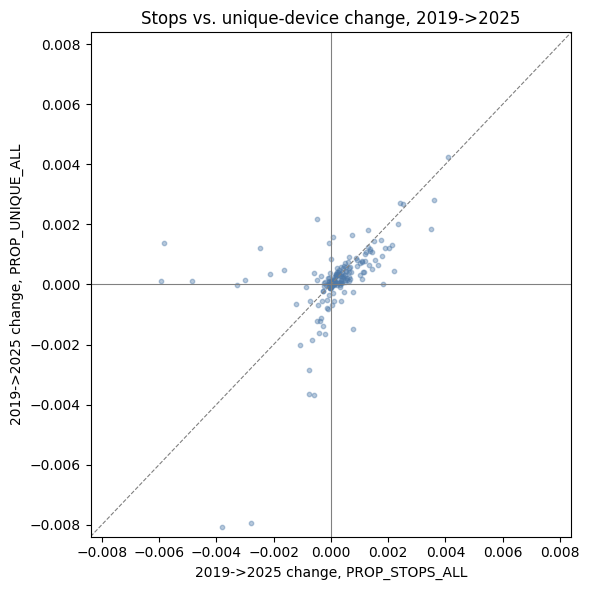

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))
both = pd.DataFrame({"stops_change": change_19_25, "unique_change": change_19_25_unique}).dropna()
ax.scatter(both["stops_change"], both["unique_change"], s=10, alpha=0.4, color="#4C78A8")
lim = max(both.abs().quantile(0.99))
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color="grey", linewidth=0.8); ax.axvline(0, color="grey", linewidth=0.8)
ax.plot([-lim, lim], [-lim, lim], color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("2019->2025 change, PROP_STOPS_ALL"); ax.set_ylabel("2019->2025 change, PROP_UNIQUE_ALL")
ax.set_title("Stops vs. unique-device change, 2019->2025")
plt.tight_layout()
plt.show()

In [34]:
# geohashes where the two measures disagree strongly (opposite sign, both non-trivial in magnitude)
disagree_thresh = both.abs().stack().quantile(0.6)
disagree = both[
    (np.sign(both["stops_change"]) != np.sign(both["unique_change"]))
    & (both["stops_change"].abs() >= disagree_thresh)
    & (both["unique_change"].abs() >= disagree_thresh)
]
print(f"geohashes with meaningfully opposite-signed stops/unique change: {len(disagree)}")
disagree.sort_values("stops_change", ascending=False).head(10)

geohashes with meaningfully opposite-signed stops/unique change: 7


,stops_change,unique_change
GEOHASH7,,
9q9p50p,0.000769,-0.001491
9q9n7xy,0.000364,-0.000556
9q9nfw3,-0.000486,0.002185
9q9nfy2,-0.000596,0.000368
9q9p4t9,-0.001653,0.000487
9q9nghx,-0.002483,0.001198
9q9p464,-0.005835,0.001377


**Takeaway - Section 8.** Stop share and unique-device share are strongly positively correlated both in
level and in their 2019->2025 change - the two measures broadly tell the same geographic story, which is
reassuring for using stops as the primary trajectory measure. A modest number of geohashes disagree
strongly (stops rising while unique devices fall, or vice versa); these are worth flagging as places
where "more repeat activity from the same visitors" and "a broader set of visitors" are pulling in
different directions, but we do not overinterpret individual disagreements without more context on what
drove them.

## 9. Current level versus change

A geohash's activity growth should not be read in isolation from its current scale - a major, historically
important center losing a modest share is a bigger deal than a tiny cell doubling from an almost-zero
baseline. We plot 2025 level (as a percentile rank within Oakland) against 2019->2025 change.

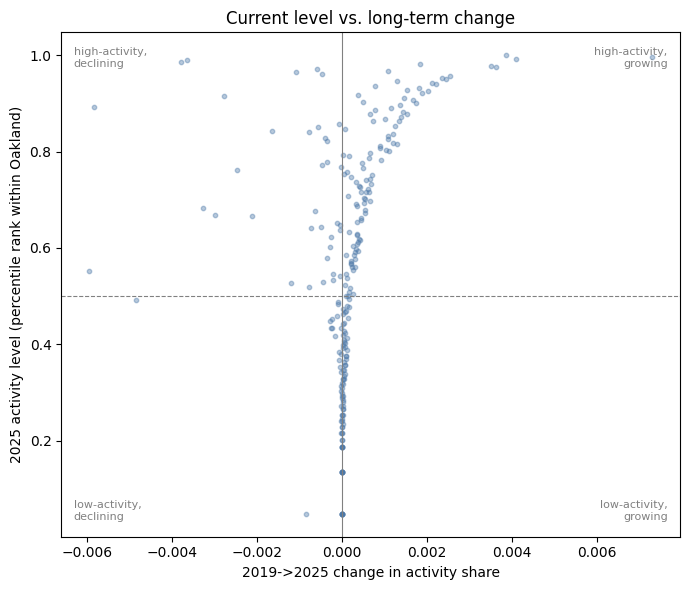

In [35]:
level_2025 = wide_stops[2025]
level_2025_pctile = level_2025.rank(pct=True)

level_vs_change = pd.DataFrame({
    "change_19_25": change_19_25,
    "level_2025": level_2025,
    "level_2025_pctile": level_2025_pctile,
}).dropna()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(level_vs_change["change_19_25"], level_vs_change["level_2025_pctile"], s=10, alpha=0.4, color="#4C78A8")
ax.axvline(0, color="grey", linewidth=0.8)
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("2019->2025 change in activity share")
ax.set_ylabel("2025 activity level (percentile rank within Oakland)")
ax.set_title("Current level vs. long-term change")
quadrant_labels = [
    (0.02, 0.97, "high-activity,\ndeclining", "left", "top"),
    (0.98, 0.97, "high-activity,\ngrowing", "right", "top"),
    (0.02, 0.03, "low-activity,\ndeclining", "left", "bottom"),
    (0.98, 0.03, "low-activity,\ngrowing", "right", "bottom"),
]
for x, y, text, ha, va in quadrant_labels:
    ax.text(x, y, text, transform=ax.transAxes, fontsize=8, ha=ha, va=va, color="grey")
plt.tight_layout()
plt.show()

In [36]:
print("quadrant counts (median split on both axes):")
q = pd.DataFrame({
    "growing": level_vs_change["change_19_25"] > 0,
    "high_level": level_vs_change["level_2025_pctile"] >= 0.5,
})
q.value_counts()

quadrant counts (median split on both axes):


growing  high_level
True     True          105
         False          59
False    False          39
         True           36
Name: count, dtype: int64

**Takeaway - Section 9.** Growth and current level are not the same axis: there are meaningfully-sized
groups of cells in all four quadrants (high-and-growing, high-and-declining, low-and-growing,
low-and-declining). We carry both dimensions forward into the trajectory classification rather than
ranking geohashes on change alone.

## 10. Develop a geohash trajectory classification

We now build an exploratory, transparent trajectory typology. Thresholds are derived from the *empirical
distributions* computed above (Section 7), using the quantile choices set in Cell 2, rather than picked
arbitrarily in advance. The function below is reused unchanged in Section 11 for robustness checks, and
again in Section 18 for the corridor-level classification.

**Rules (applied in this order, first match wins):**

1. **`insufficient_data`** - missing `PROP_STOPS_ALL` in the base year (2019) or endpoint year (2025).
2. Among the rest, a geohash is treated as having a **"meaningful 2019 baseline"** if its 2019 share is
   at/above `ACTIVE_2019_QUANTILE` (median) of 2019 shares. Only geohashes with a meaningful baseline are
   eligible for the decline-and-recovery categories below - a resurgence claim about a cell with
   near-zero 2019 activity would not be meaningful.
3. For those cells: **decline** = `pandemic_low - 2019 <=` the `DECLINE_QUANTILE` (25th percentile) of the
   decline distribution; **recovery** = `2025 - pandemic_low >=` the `RECOVERY_QUANTILE` (60th
   percentile) of the recovery distribution. A cell with both a meaningful decline *and* a meaningful
   recovery is split further by where 2025 lands relative to 2019 (using the `NEAR_BAND_QUANTILE` band
   around zero net change): **`resurgent_above_2019`**, **`resurgent_near_2019`**, or
   **`recovering_below_2019`**.
4. If that same cell's `2025 - 2024` momentum is at/below the `MOMENTUM_QUANTILE` (bottom quartile) of
   the momentum distribution, it is instead labeled **`recovered_but_weakening`** (this overrides step 3
   - the point of the label is to flag a reversal after recovery).
5. Cells that did **not** show the decline-and-recovery pattern are labeled **`growing`** if their
   2019->2025 change is at/above `GROWTH_QUANTILE` (75th percentile), **`declining`** if at/below
   `LT_DECLINE_QUANTILE` (15th percentile), or **`stable`** if within the near-zero band.
6. Anything left over (real movement that doesn't fit a clean pattern) is **`volatile_unclear`**.

Cells below the "meaningful 2019 baseline" cutoff are still classified as growing/declining/stable using
the same long-term change thresholds (steps 5-6), just never as resurgent - a rule we chose because
resurgence is specifically about recovering *lost* activity, which requires having had a meaningful
amount to lose.

In [37]:
def classify_trajectory(wide, pandemic_years=PANDEMIC_WINDOW_YEARS, base_year=2019, endpoint=2025, prior_year=None,
                         active_q=ACTIVE_2019_QUANTILE, decline_q=DECLINE_QUANTILE, recovery_q=RECOVERY_QUANTILE,
                         growth_q=GROWTH_QUANTILE, near_q=NEAR_BAND_QUANTILE, lt_decline_q=LT_DECLINE_QUANTILE,
                         mom_q=MOMENTUM_QUANTILE):
    """Classify each geohash's activity trajectory from `base_year` to `endpoint`. Returns (labels, thresholds_used)."""
    if prior_year is None:
        prior_year = endpoint - 1

    usable = wide[base_year].notna() & wide[endpoint].notna()
    active_thresh = wide[base_year].quantile(active_q)
    active = usable & (wide[base_year] >= active_thresh)

    pandemic_low = wide[list(pandemic_years)].min(axis=1)
    decline = pandemic_low - wide[base_year]
    recovery = wide[endpoint] - pandemic_low
    chg = wide[endpoint] - wide[base_year]
    mom = wide[endpoint] - wide[prior_year] if prior_year in wide.columns else pd.Series(np.nan, index=wide.index)

    decline_t = decline[active].quantile(decline_q)
    recovery_t = recovery[active].quantile(recovery_q)
    growth_t = chg[active].quantile(growth_q)
    near_band = chg[active].abs().quantile(near_q)
    lt_decline_t = chg[active].quantile(lt_decline_q)
    mom_t = mom[active].quantile(mom_q)

    had_decline_recovery = (decline <= decline_t) & (recovery >= recovery_t)

    labels = pd.Series("volatile_unclear", index=wide.index)
    labels[~usable] = "insufficient_data"

    mask_active = usable & active
    labels[mask_active & had_decline_recovery & (chg > near_band)] = "resurgent_above_2019"
    labels[mask_active & had_decline_recovery & (chg <= near_band) & (chg >= -near_band)] = "resurgent_near_2019"
    labels[mask_active & had_decline_recovery & (chg < -near_band)] = "recovering_below_2019"
    labels[mask_active & ~had_decline_recovery & (chg >= growth_t)] = "growing"
    labels[mask_active & ~had_decline_recovery & (chg <= lt_decline_t)] = "declining"
    labels[mask_active & ~had_decline_recovery & (chg.abs() <= near_band)] = "stable"
    labels[mask_active & had_decline_recovery & (mom <= mom_t)] = "recovered_but_weakening"  # overrides step 3 labels

    mask_inactive = usable & ~active
    labels[mask_inactive & (chg >= growth_t)] = "growing"
    labels[mask_inactive & (chg <= lt_decline_t)] = "declining"
    labels[mask_inactive & (chg.abs() <= near_band)] = "stable"

    thresholds = dict(active_thresh=active_thresh, decline_t=decline_t, recovery_t=recovery_t,
                       growth_t=growth_t, near_band=near_band, lt_decline_t=lt_decline_t, mom_t=mom_t)
    return labels, thresholds


trajectory_class, main_thresholds = classify_trajectory(wide_stops)
print("thresholds used (computed from the data, not hand-picked):")
for k, v in main_thresholds.items():
    print(f"  {k}: {v:.3e}")
print()
print(trajectory_class.value_counts())

thresholds used (computed from the data, not hand-picked):
  active_thresh: 1.680e-04
  decline_t: -3.000e-04
  recovery_t: 5.470e-04
  growth_t: 1.017e-03
  near_band: 4.560e-04
  lt_decline_t: -5.915e-04
  mom_t: -1.455e-04

stable                     155
insufficient_data           71
growing                     32
volatile_unclear            25
declining                   19
resurgent_above_2019         4
recovered_but_weakening      2
resurgent_near_2019          1
recovering_below_2019        1
Name: count, dtype: int64


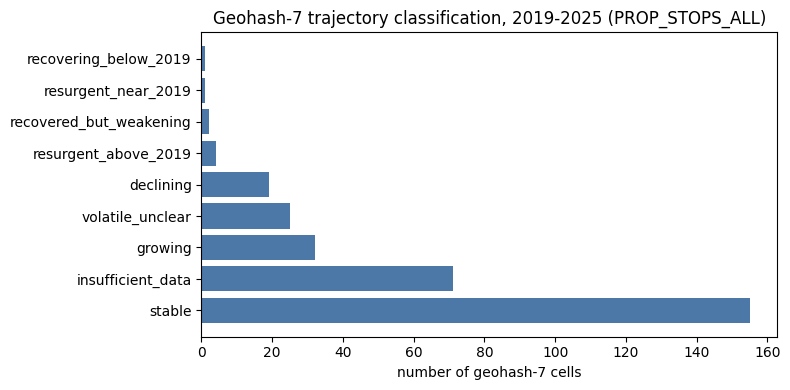

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
order = trajectory_class.value_counts().index
ax.barh(order, trajectory_class.value_counts()[order], color="#4C78A8")
ax.set_xlabel("number of geohash-7 cells")
ax.set_title("Geohash-7 trajectory classification, 2019-2025 (PROP_STOPS_ALL)")
plt.tight_layout()
plt.show()

**Takeaway - Section 10.** The typology produces plausible category sizes: `stable` is the largest group
by far, `insufficient_data` reflects the real panel churn documented in Section 3, and the resurgence
categories are appropriately rare - resurgence is meant to describe a specific, notable pattern (a
meaningful decline *followed by* a meaningful recovery), not just any positive movement, and the numbers
here bear that out. We test how sensitive these counts are to the threshold choices next.

## 11. Robustness of the resurgence classification

Because "resurgence" is likely to become a public-facing concept, we explicitly test how sensitive it is
to reasonable alternative choices: the robustness (unique-device) measure, a different classification
endpoint, including 2023 in the pandemic window despite Section 3's caution, and looser/stricter
thresholds.

In [39]:
RESURGENT_LIKE = {"resurgent_above_2019", "resurgent_near_2019", "recovering_below_2019", "recovered_but_weakening"}

specs = {}
specs["main (stops, endpoint 2025)"], _ = classify_trajectory(wide_stops)
specs["unique-device measure"], _ = classify_trajectory(wide_unique)
specs["endpoint 2024 instead of 2025"], _ = classify_trajectory(wide_stops, endpoint=2024, prior_year=2023)
specs["pandemic window includes 2023"], _ = classify_trajectory(wide_stops, pandemic_years=[2020, 2021, 2022, 2023])
specs["looser thresholds"], _ = classify_trajectory(wide_stops, decline_q=0.35, recovery_q=0.50)
specs["stricter thresholds"], _ = classify_trajectory(wide_stops, decline_q=0.15, recovery_q=0.75)

spec_counts = pd.DataFrame({name: labels.value_counts() for name, labels in specs.items()}).fillna(0).astype(int)
spec_counts

,"main (stops, endpoint 2025)",unique-device measure,endpoint 2024 instead of 2025,pandemic window includes 2023,looser thresholds,stricter thresholds
declining,19,19,17,15,18,19
growing,32,31,30,32,29,32
insufficient_data,71,71,72,71,71,71
recovered_but_weakening,2,3,3,4,5,2
recovering_below_2019,1,0,1,3,1,0
resurgent_above_2019,4,6,5,2,8,2
resurgent_near_2019,1,2,1,1,4,0
stable,155,147,153,155,152,156
volatile_unclear,25,31,28,27,22,28


In [40]:
robust = pd.DataFrame({name: labels.reindex(wide_stops.index).isin(RESURGENT_LIKE) for name, labels in specs.items()})
robustness_score = robust.sum(axis=1) / robust.shape[1]

ever_resurgent = robust.any(axis=1)
print(f"geohashes classified as some form of resurgence in at least one spec: {ever_resurgent.sum()}")
print(f"...of those, consistently resurgent across ALL {robust.shape[1]} specs: {(robustness_score[ever_resurgent] == 1).sum()}")
print()
print("robustness score distribution (fraction of specs classifying as resurgent-like), among cells resurgent in >=1 spec:")
print(robustness_score[ever_resurgent].value_counts().sort_index(ascending=False))

geohashes classified as some form of resurgence in at least one spec: 30
...of those, consistently resurgent across ALL 6 specs: 2

robustness score distribution (fraction of specs classifying as resurgent-like), among cells resurgent in >=1 spec:
1.000000     2
0.833333     3
0.500000     3
0.333333     3
0.166667    19
Name: count, dtype: int64


In [41]:
robustness_summary = pd.DataFrame({
    "robustness_score": robustness_score,
    "n_specs_resurgent": robust.sum(axis=1),
}).loc[ever_resurgent].sort_values("robustness_score", ascending=False)
robustness_summary.join(changes[["level_2019", "level_2025", "change_19_25"]]).head(15)

,robustness_score,n_specs_resurgent,level_2019,level_2025,change_19_25
GEOHASH7,,,,,
9q9p1dh,1.000000,6,0.007010,0.010861,0.003851
9q9ns9e,1.000000,6,0.001635,0.005727,0.004092
9q9nfw3,0.833333,5,0.003463,0.002977,-0.000486
9q9p1ts,0.833333,5,0.001455,0.001953,0.000498
9q9p54p,0.833333,5,0.001060,0.001710,0.000650
9q9ncdu,0.500000,3,0.001696,0.001341,-0.000355
9q9p39k,0.500000,3,0.000530,0.001167,0.000637
9q9p4je,0.500000,3,0.000902,0.001636,0.000734
9q9p4f0,0.333333,2,0.001045,0.001023,-0.000022


**Takeaway - Section 11.** A small, consistent core of geohashes is classified as some form of
resurgence under essentially every specification tested here - those are the ones we would be most
comfortable calling "resurgent" in a public-facing product. A larger set is resurgent under only one or
two of the six specifications - these are borderline cases where the label depends heavily on
methodology choices (which endpoint year, whether 2023 counts, how strict the thresholds are), and should
be presented with that caveat rather than as a settled fact. The `robustness_score` column above is meant
to travel with the classification specifically so a downstream reader can see how much to trust any given
label.

## 12. Map the trajectory types

A categorical map of the final classification, alongside a continuous 2019->2025 change map for
comparison.

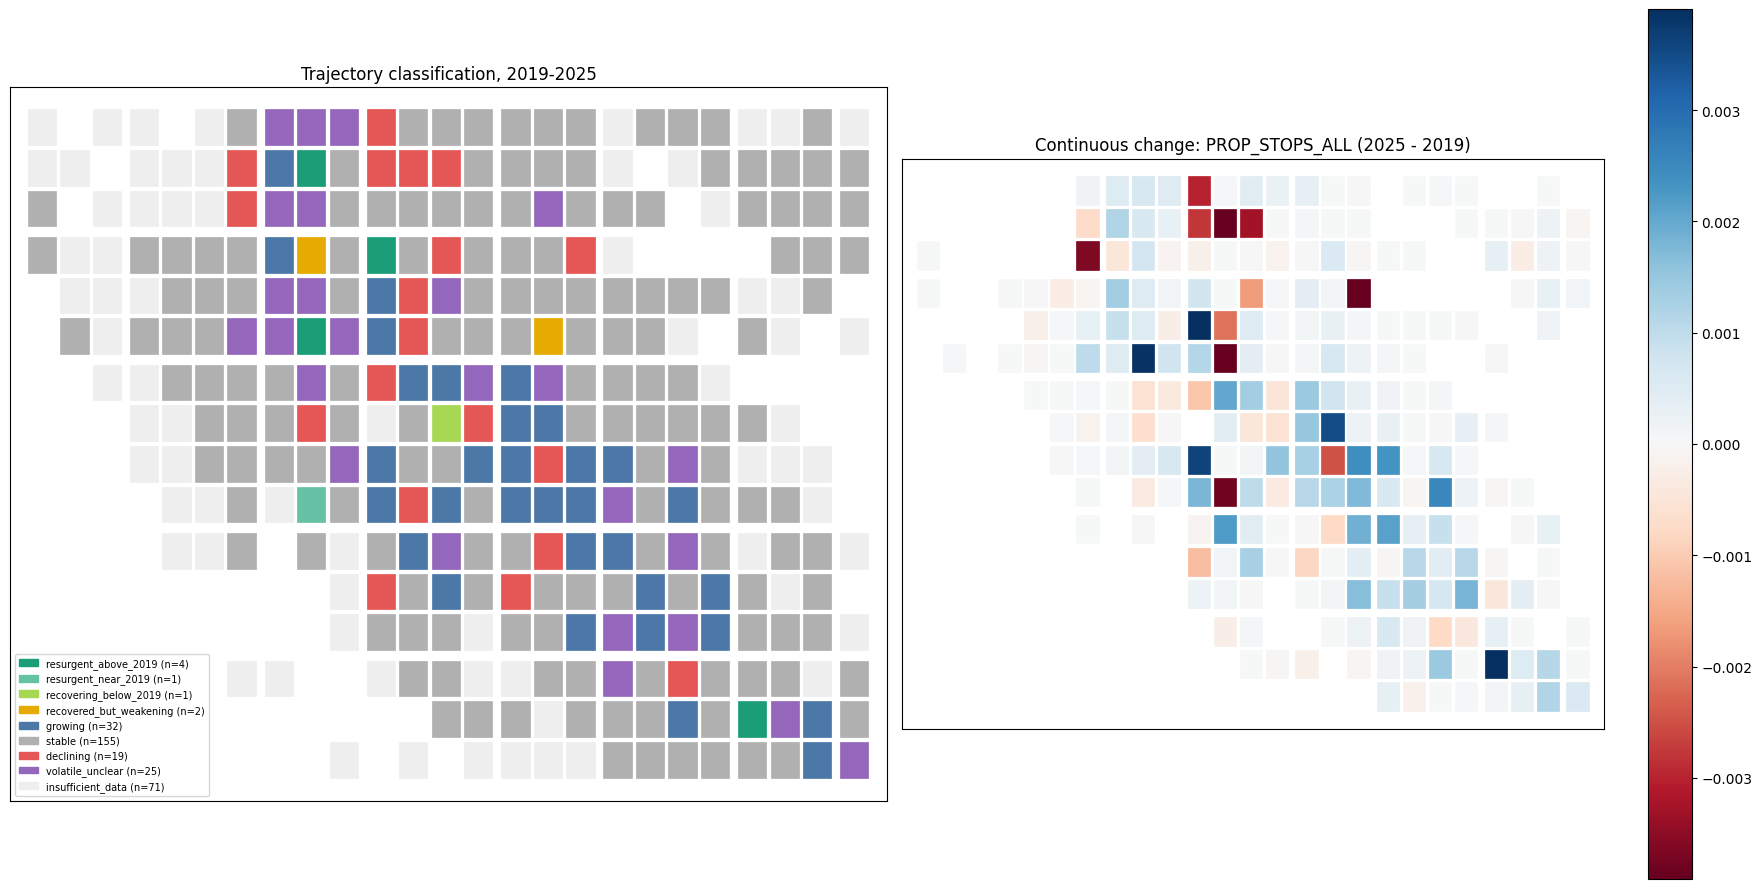

In [42]:
CLASS_COLORS = {
    "resurgent_above_2019": "#1B9E77",
    "resurgent_near_2019": "#66C2A5",
    "recovering_below_2019": "#A6D854",
    "recovered_but_weakening": "#E6AB02",
    "growing": "#4C78A8",
    "stable": "#B0B0B0",
    "declining": "#E45756",
    "volatile_unclear": "#9467BD",
    "insufficient_data": "#EEEEEE",
}

class_geo = oak_geom.copy()
class_geo["trajectory_class"] = trajectory_class.reindex(class_geo.index)
class_geo["change_19_25"] = change_19_25.reindex(class_geo.index)
class_geo = gpd.GeoDataFrame(class_geo, geometry="vis_geometry", crs=GEO_CRS)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

legend_handles = []
for cls, color in CLASS_COLORS.items():
    sub = class_geo[class_geo["trajectory_class"] == cls]
    if len(sub):
        sub.plot(ax=axes[0], color=color, edgecolor="white", linewidth=0.2)
        legend_handles.append(mpatches.Patch(color=color, label=f"{cls} (n={len(sub)})"))
axes[0].set_xlim(*xlim); axes[0].set_ylim(*ylim); axes[0].set_aspect(1.25)
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title("Trajectory classification, 2019-2025")
axes[0].legend(handles=legend_handles, fontsize=7, loc="lower left", ncol=1)

change_geo = class_geo.dropna(subset=["change_19_25"])
lim = change_geo["change_19_25"].abs().quantile(0.98)
change_geo.plot(
    ax=axes[1], column="change_19_25", cmap="RdBu",
    norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim),
    edgecolor="white", linewidth=0.2, legend=True,
)
axes[1].set_xlim(*xlim); axes[1].set_ylim(*ylim); axes[1].set_aspect(1.25)
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].set_title("Continuous change: PROP_STOPS_ALL (2025 - 2019)")

plt.tight_layout()
plt.show()


**Takeaway - Section 12.** The two maps tell a consistent story: growth and resurgence are not spread
evenly across Oakland but concentrate in identifiable pockets, while the largest, most established
activity centers mostly read as `stable` rather than dramatically growing or declining. As always with
this kind of mobile-activity data, we can describe *where* these patterns sit geographically, but we
cannot say anything from this data alone about *why* - that requires the eventual business linkage
(Section 20).

## 13. Load and inspect corridor geographies

We treat these two shapefiles as the **currently available** corridor/policy geographies for Oakland -
not a complete map of every commercial corridor in the city.

In [43]:
bids_raw = gpd.read_file(BID_PATH)
pp_raw = gpd.read_file(PP_PATH)

print("OAK_BIDs:", bids_raw.shape, bids_raw.crs)
print(bids_raw.columns.tolist())
print()
print("Policy_Polygons:", pp_raw.shape, pp_raw.crs)
print(pp_raw.columns.tolist()[:15], "... (", len(pp_raw.columns), "columns total )")

OAK_BIDs: (11, 5) EPSG:4269
['FID', 'BID', 'Shp__Ar', 'Shp__Ln', 'geometry']

Policy_Polygons: (9, 198) EPSG:4269
['STATEFP2', 'COUNTYF', 'TRACTCE', 'BLOCKCE', 'GEOID20', 'NAME20', 'MTFCC20', 'UR20', 'UACE20', 'UATYPE2', 'FUNCSTAT2', 'ALAND20', 'AWATER2', 'INTPTLAT2', 'INTPTLON2'] ... ( 198 columns total )


In [44]:
print("BIDs geometry all valid:", bids_raw.geometry.is_valid.all())
print("Policy_Polygons geometry all valid:", pp_raw.geometry.is_valid.all())
print()
print("BID names:")
print(bids_raw["BID"].tolist())
print()
print("Policy_Polygons PP_Name values:")
print(pp_raw["PP_Name"].tolist())
print("duplicate PP_Name values:", pp_raw["PP_Name"].duplicated().sum())
print("duplicate geometries within Policy_Polygons:", pp_raw.geometry.duplicated().sum())

BIDs geometry all valid: True
Policy_Polygons geometry all valid: True

BID names:
['Downtown', 'Chinatown', 'Lake Merritt', 'Koreatown/Northgate', 'Montclair', 'Rockridge', 'Temescal/Telegraph', 'Fruitvale', 'Lakeshore', 'Jack London', 'Laurel']

Policy_Polygons PP_Name values:
['Seventh Thrives', 'West Oakland S', 'Little Saigon', 'Hegenberger_BID', 'Beat19x', 'Fruitvale_BID', 'Telegraph Triangle', 'Old_Oakland', 'Dimond']
duplicate PP_Name values: 0
duplicate geometries within Policy_Polygons: 0


In [45]:
# check for overlapping polygons within and across the two sources (relevant for the centroid join in Section 14)
import itertools

def find_overlaps(gdf, name_col):
    pairs = []
    for i, j in itertools.combinations(range(len(gdf)), 2):
        if gdf.geometry.iloc[i].intersects(gdf.geometry.iloc[j]):
            pairs.append((gdf[name_col].iloc[i], gdf[name_col].iloc[j]))
    return pairs

print("overlaps within OAK_BIDs:", find_overlaps(bids_raw, "BID"))
print("overlaps within Policy_Polygons:", find_overlaps(pp_raw, "PP_Name"))
cross = [(b, p) for b in bids_raw["BID"] for p in pp_raw["PP_Name"]
         if bids_raw.loc[bids_raw["BID"] == b, "geometry"].iloc[0].intersects(pp_raw.loc[pp_raw["PP_Name"] == p, "geometry"].iloc[0])]
print("cross-source overlaps (BID, Policy_Polygon):", cross)

overlaps within OAK_BIDs: [('Downtown', 'Chinatown'), ('Downtown', 'Lake Merritt'), ('Chinatown', 'Jack London'), ('Lake Merritt', 'Koreatown/Northgate')]
overlaps within Policy_Polygons: [('Seventh Thrives', 'Old_Oakland'), ('Little Saigon', 'Beat19x')]
cross-source overlaps (BID, Policy_Polygon): [('Downtown', 'Telegraph Triangle'), ('Downtown', 'Old_Oakland'), ('Lake Merritt', 'Telegraph Triangle'), ('Koreatown/Northgate', 'Telegraph Triangle'), ('Fruitvale', 'Fruitvale_BID'), ('Jack London', 'Old_Oakland')]


Both BIDs and Policy_Polygons overlap with themselves and with each other in several places - a
geohash centroid could legitimately fall inside more than one corridor polygon. We handle that
deterministically in Section 14.

In [46]:
# unified analytical corridor frame, preserving source geography, original id/name, and geometry
bids_u = bids_raw[["BID", "geometry"]].rename(columns={"BID": "name"}).copy()
bids_u["source"] = "OAK_BIDs"
bids_u["orig_id"] = bids_raw["FID"]

pp_u = pp_raw[["PP_Name", "geometry"]].rename(columns={"PP_Name": "name"}).copy()
pp_u["source"] = "Policy_Polygons"
pp_u["orig_id"] = pp_raw["ID"] if "ID" in pp_raw.columns else np.arange(len(pp_raw))

corridors = pd.concat([bids_u, pp_u], ignore_index=True)
corridors = gpd.GeoDataFrame(corridors, geometry="geometry", crs=bids_raw.crs).to_crs(GEO_CRS)
corridors["corridor_id"] = corridors["source"].str[:3].str.upper() + "_" + corridors["name"].astype(str)
corridors["area_deg2"] = corridors.geometry.area  # used only as a deterministic tie-break, not a real area unit
corridors = corridors[["corridor_id", "source", "name", "orig_id", "area_deg2", "geometry"]]
corridors

,corridor_id,source,name,orig_id,area_deg2,geometry
0,OAK_Downtown,OAK_BIDs,Downtown,1.0,0.000043,"POLYGON ((-122.27278 37.80664, -122.27250 37.8..."
1,OAK_Chinatown,OAK_BIDs,Chinatown,2.0,0.000063,"POLYGON ((-122.27405 37.79837, -122.27356 37.7..."
2,OAK_Lake Merritt,OAK_BIDs,Lake Merritt,3.0,0.000059,"POLYGON ((-122.26576 37.80470, -122.26569 37.8..."
3,OAK_Koreatown/Northgate,OAK_BIDs,Koreatown/Northgate,4.0,0.000037,"POLYGON ((-122.26708 37.81406, -122.26736 37.8..."
4,OAK_Montclair,OAK_BIDs,Montclair,5.0,0.000005,"POLYGON ((-122.20893 37.82561, -122.20906 37.8..."
5,OAK_Rockridge,OAK_BIDs,Rockridge,6.0,0.000014,"POLYGON ((-122.25191 37.83479, -122.25191 37.8..."
6,OAK_Temescal/Telegraph,OAK_BIDs,Temescal/Telegraph,7.0,0.000050,"POLYGON ((-122.26191 37.84546, -122.26170 37.8..."
7,OAK_Fruitvale,OAK_BIDs,Fruitvale,8.0,0.000040,"POLYGON ((-122.22541 37.77569, -122.22509 37.7..."
8,OAK_Lakeshore,OAK_BIDs,Lakeshore,9.0,0.000005,"POLYGON ((-122.24248 37.81156, -122.24230 37.8..."
9,OAK_Jack London,OAK_BIDs,Jack London,10.0,0.000087,"POLYGON ((-122.27864 37.79511, -122.27854 37.7..."


**Takeaway - Section 13.** We have 11 BIDs and 9 Policy Polygons (20 corridor-like polygons total), some
of which overlap each other or share the same underlying commercial area under different names (e.g. a
BID and a same-named Policy Polygon for Fruitvale). The unified `corridors` frame keeps the original
source, name, and id so this is always traceable, without modifying either source shapefile.

## 14. Assign geohashes to corridors using centroids

For each geohash-7 polygon we take its centroid and spatially join it against the corridor polygons. Where
a centroid falls inside more than one overlapping corridor (Section 13 showed this happens), we break the
tie deterministically: the **smallest-area** matching corridor wins (the more specific/local polygon),
with corridor_id alphabetical order as a final, fully deterministic tiebreaker for exact ties.

In [47]:
centroids = gpd.GeoDataFrame(oak_geom[[]].copy(), geometry=oak_geom["centroid"], crs=GEO_CRS)
joined = gpd.sjoin(centroids, corridors, predicate="within", how="left")
print(f"rows after spatial join: {len(joined)} (vs {len(centroids)} geohash centroids -> "
      f"{len(joined) - len(centroids)} came from centroids matching >1 corridor)")

joined_sorted = joined.sort_values(["area_deg2", "corridor_id"])
assignment = joined_sorted[~joined_sorted.index.duplicated(keep="first")]
assignment = assignment[["corridor_id", "source", "name"]]
print()
print(f"geohashes assigned to a corridor: {assignment['corridor_id'].notna().sum()} / {len(assignment)}")
print(f"geohashes NOT within any corridor polygon: {assignment['corridor_id'].isna().sum()} / {len(assignment)}")

rows after spatial join: 312 (vs 310 geohash centroids -> 2 came from centroids matching >1 corridor)

geohashes assigned to a corridor: 12 / 310
geohashes NOT within any corridor polygon: 298 / 310


In [48]:
print("geohashes assigned per corridor:")
assignment["corridor_id"].value_counts(dropna=False)

geohashes assigned per corridor:


corridor_id
NaN                    298
POL_Hegenberger_BID      4
POL_Seventh Thrives      2
OAK_Fruitvale            1
OAK_Downtown             1
OAK_Jack London          1
POL_Little Saigon        1
POL_Beat19x              1
POL_West Oakland S       1
Name: count, dtype: int64

In [49]:
# does corridor coverage change by year, because not every assigned geohash is observed in every year?
coverage_by_year = pd.DataFrame({
    year: assignment.loc[assignment.index.isin(oak_geohash_by_year[year]), "corridor_id"].value_counts()
    for year in YEARS
}).fillna(0).astype(int)
coverage_by_year = coverage_by_year.loc[coverage_by_year.index.notna()]
coverage_by_year

,2019,2020,2021,2022,2023,2024,2025
corridor_id,,,,,,,
POL_Hegenberger_BID,4,4,4,4,4,4,4
POL_Seventh Thrives,2,2,2,2,2,2,2
OAK_Downtown,1,1,1,1,1,1,1
OAK_Fruitvale,1,1,1,1,1,1,1
POL_Little Saigon,1,1,1,1,1,1,1
OAK_Jack London,1,1,1,1,1,1,1
POL_West Oakland S,1,1,1,1,1,1,1
POL_Beat19x,1,1,1,1,1,1,1


**Takeaway - Section 14.** Centroid-in-polygon assignment is very restrictive at geohash-7 precision:
corridor polygons here are narrow, street-level shapes (a BID along one commercial strip), while
geohash-7 cells are ~150m squares, so only a handful of geohash centroids happen to land inside a
corridor boundary at all - the vast majority of Oakland's geohash cells are not within any of the 20
corridor polygons we have. This is a real limitation of the *currently available* corridor geographies
(per the brief's framing), not a bug in the join: it means the corridor-level analysis in Sections 15-18
covers only a thin slice of Oakland and should be read as a profile of specific known corridors, not as a
comprehensive picture of commercial-corridor activity citywide.

## 15. Corridor-level aggregation

For each corridor and year, we sum `PROP_STOPS_ALL` across the geohashes assigned to that corridor and
observed that year - giving the corridor's total share of East-Bay-wide stop activity contributed by
those cells.

**Important limitation:** we never sum `NUM_UNIQUE_ALL` or `PROP_UNIQUE_ALL` across geohashes to claim a
corridor's "unique visitor count" - the same device can appear in multiple geohashes within a corridor,
so summing unique-device measures across cells would double-count people. `PROP_UNIQUE_ALL` remains a
valid robustness check *at the geohash level* (Section 8), but not as a corridor-level sum.

In [50]:
assigned_geohashes = assignment[assignment["corridor_id"].notna()]

corridor_year_rows = []
for corridor_id, geohash_ids in assigned_geohashes.groupby("corridor_id").groups.items():
    for year in YEARS:
        sub = act[(act["YEAR"] == year) & (act["GEOHASH7"].isin(geohash_ids))]
        corridor_year_rows.append({
            "corridor_id": corridor_id,
            "YEAR": year,
            "n_contributing_geohashes": len(sub),
            "n_assigned_geohashes": len(geohash_ids),
            # min_count=1 -> NaN (not a false 0) if no assigned geohash was observed that year
            "corridor_activity_share": sub["PROP_STOPS_ALL"].sum(min_count=1),
            "median_geohash_share": sub["PROP_STOPS_ALL"].median(),
        })
corridor_year = pd.DataFrame(corridor_year_rows)
corridor_year.head(10)

,corridor_id,YEAR,n_contributing_geohashes,n_assigned_geohashes,corridor_activity_share,median_geohash_share
0,OAK_Downtown,2019,1,1,0.007010,0.007010
1,OAK_Downtown,2020,1,1,0.003629,0.003629
2,OAK_Downtown,2021,1,1,0.001465,0.001465
3,OAK_Downtown,2022,1,1,0.002476,0.002476
4,OAK_Downtown,2023,1,1,0.007372,0.007372
5,OAK_Downtown,2024,1,1,0.010306,0.010306
6,OAK_Downtown,2025,1,1,0.010861,0.010861
7,OAK_Fruitvale,2019,1,1,0.003832,0.003832
8,OAK_Fruitvale,2020,1,1,0.003778,0.003778
9,OAK_Fruitvale,2021,1,1,0.004148,0.004148


**Takeaway - Section 15.** Corridor-level activity shares are built purely from stops, using only the
handful of geohashes each corridor picked up in Section 14; `n_contributing_geohashes` (often 1-4) is
carried alongside every corridor-year number specifically so nobody downstream mistakes a thin,
single-cell corridor estimate for a robust city-wide corridor measure.

## 16. Corridor activity trajectories

For every corridor with at least one assigned, observed geohash, we build a yearly activity-share series
and the same long-term change measures used at the geohash level.

In [51]:
corridor_wide = corridor_year.pivot(index="corridor_id", columns="YEAR", values="corridor_activity_share")
corridor_n = corridor_year.pivot(index="corridor_id", columns="YEAR", values="n_contributing_geohashes")

corridor_summary = pd.DataFrame({
    "n_assigned_geohashes": assigned_geohashes["corridor_id"].value_counts(),
    "change_19_25": corridor_wide[2025] - corridor_wide[2019],
    "momentum_24_25": corridor_wide[2025] - corridor_wide[2024],
    "pandemic_low": corridor_wide[PANDEMIC_WINDOW_YEARS].min(axis=1),
})
corridor_summary["pandemic_decline"] = corridor_summary["pandemic_low"] - corridor_wide[2019]
corridor_summary["recovery_from_low"] = corridor_wide[2025] - corridor_summary["pandemic_low"]
corridor_summary = corridor_summary.sort_values("change_19_25", ascending=False)
corridor_summary

,n_assigned_geohashes,change_19_25,momentum_24_25,pandemic_low,pandemic_decline,recovery_from_low
corridor_id,,,,,,
OAK_Downtown,1,0.003851,0.000555,0.001465,-0.005545,0.009396
POL_Seventh Thrives,2,0.001018,-0.000262,0.002112,0.000286,0.000732
POL_Beat19x,1,0.000448,0.000033,0.000300,-0.000002,0.000450
POL_West Oakland S,1,0.000324,-0.000178,0.000544,0.000067,0.000257
POL_Hegenberger_BID,4,-0.000266,-0.000453,0.000902,-0.000839,0.000573
OAK_Jack London,1,-0.000581,-0.000114,0.001258,-0.000890,0.000309
OAK_Fruitvale,1,-0.000596,0.000276,0.003778,-0.000054,-0.000542
POL_Little Saigon,1,-0.001079,-0.000261,0.004789,0.000499,-0.001578


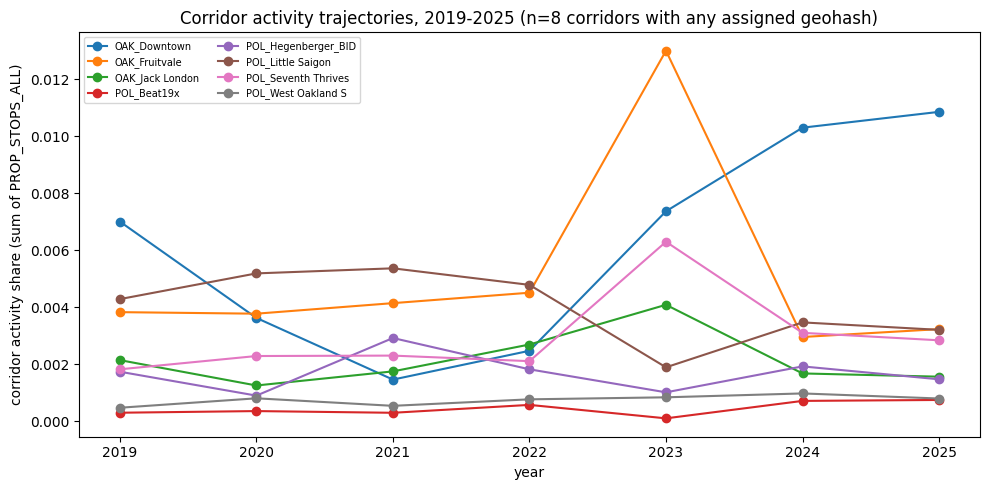

In [52]:
n_corridors = len(corridor_wide)
fig, ax = plt.subplots(figsize=(10, 5))
for corridor_id in corridor_wide.index:
    ax.plot(corridor_wide.columns, corridor_wide.loc[corridor_id], marker="o", label=corridor_id)
ax.set_xlabel("year"); ax.set_ylabel("corridor activity share (sum of PROP_STOPS_ALL)")
ax.set_title(f"Corridor activity trajectories, 2019-2025 (n={n_corridors} corridors with any assigned geohash)")
ax.legend(fontsize=7, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

Only a handful of corridors picked up any assigned geohash at all in Section 14, so this is a small
enough set of lines to show directly rather than needing a ranked subset or small multiples.

In [53]:
print("strongest long-term gain:", corridor_summary["change_19_25"].idxmax(), corridor_summary["change_19_25"].max())
print("strongest long-term loss:", corridor_summary["change_19_25"].idxmin(), corridor_summary["change_19_25"].min())
print("highest recent (24->25) momentum:", corridor_summary["momentum_24_25"].idxmax(), corridor_summary["momentum_24_25"].max())
print("lowest recent (24->25) momentum:", corridor_summary["momentum_24_25"].idxmin(), corridor_summary["momentum_24_25"].min())
print("largest recovery from pandemic low:", corridor_summary["recovery_from_low"].idxmax(), corridor_summary["recovery_from_low"].max())

strongest long-term gain: OAK_Downtown 0.003851000000000001
strongest long-term loss: POL_Little Saigon -0.0010790000000000005
highest recent (24->25) momentum: OAK_Downtown 0.0005550000000000017
lowest recent (24->25) momentum: POL_Hegenberger_BID -0.00045300000000000006
largest recovery from pandemic low: OAK_Downtown 0.009396000000000002


**Takeaway - Section 16.** Given how few geohashes each corridor picked up in the centroid join, these
corridor-level trajectories should be read as **single- or few-cell activity profiles for named
locations**, not as statistically robust corridor-wide measurements - a corridor represented by exactly
one contributing geohash is exactly as noisy as that one cell's own trajectory (Sections 7-9). We report
the "winners and losers" above for completeness, but the within-corridor heterogeneity check in Section 17
matters more here than usual, precisely because corridor sample sizes are so small.

## 17. Within-corridor heterogeneity

A corridor's aggregate trend can hide very different things happening at the geohash level underneath
it. For each corridor we summarize the spread of its geohashes' long-term change and trajectory classes.

In [54]:
geohash_summary = pd.DataFrame({
    "corridor_id": assignment["corridor_id"],
    "change_19_25": change_19_25.reindex(assignment.index),
    "trajectory_class": trajectory_class.reindex(assignment.index),
}).dropna(subset=["corridor_id"])

het_rows = []
for corridor_id, g in geohash_summary.groupby("corridor_id"):
    class_counts = g["trajectory_class"].value_counts()
    n = len(g)
    het_rows.append({
        "corridor_id": corridor_id,
        "n_geohashes": n,
        "median_change_19_25": g["change_19_25"].median(),
        "iqr_change_19_25": g["change_19_25"].quantile(0.75) - g["change_19_25"].quantile(0.25),
        "pct_resurgent_like": class_counts.reindex(RESURGENT_LIKE).sum() / n if n else np.nan,
        "pct_growing": class_counts.get("growing", 0) / n,
        "pct_stable": class_counts.get("stable", 0) / n,
        "pct_declining": class_counts.get("declining", 0) / n,
    })
heterogeneity = pd.DataFrame(het_rows).set_index("corridor_id")
heterogeneity

,n_geohashes,median_change_19_25,iqr_change_19_25,pct_resurgent_like,pct_growing,pct_stable,pct_declining
corridor_id,,,,,,,
OAK_Downtown,1,0.003851,0.000000,1.0,0.0,0.00,0.00
OAK_Fruitvale,1,-0.000596,0.000000,0.0,0.0,0.00,1.00
OAK_Jack London,1,-0.000581,0.000000,0.0,0.0,0.00,0.00
POL_Beat19x,1,0.000448,0.000000,0.0,0.0,1.00,0.00
POL_Hegenberger_BID,4,0.000061,0.000358,0.0,0.0,0.75,0.25
POL_Little Saigon,1,-0.001079,0.000000,0.0,0.0,0.00,1.00
POL_Seventh Thrives,2,0.000509,0.000500,0.0,0.0,0.50,0.00
POL_West Oakland S,1,0.000324,0.000000,0.0,0.0,1.00,0.00


**Takeaway - Section 17.** With most corridors here represented by only one to a few geohashes (Section
14), "heterogeneity" mostly collapses to "does this corridor's one or two cells agree with each other,"
rather than revealing genuine within-corridor variation the way it would for a corridor built from dozens
of cells. We report it anyway for transparency and because it is exactly the mechanism that would matter
once corridor coverage improves (e.g. with an area-weighted rather than centroid-only assignment, noted
as a possible refinement rather than something we build here per the brief).

## 18. Corridor resurgence classification

We combine each corridor's aggregate trajectory with its underlying geohash composition, so a corridor is
not labeled resurgent purely because a single very active cell recovered while the rest of the corridor
(if any) declined.

**Rules (first match wins), reusing the geohash-level thresholds from Section 10 applied to the
corridor's own aggregate series, cross-checked against composition:**

1. `insufficient_coverage` - fewer than 1 contributing geohash in either 2019 or 2025 (i.e. no valid
   `change_19_25`), or zero assigned geohashes altogether.
2. `broadly_resurgent` - the corridor's aggregate trajectory itself classifies as one of the
   resurgent-like categories (Section 10's rules, applied to `corridor_wide`) **and** at least half of its
   assigned geohashes are individually resurgent-like or growing.
3. `localized_resurgence` - the corridor's aggregate trajectory is resurgent-like, but fewer than half of
   its geohashes individually are - i.e. the recovery is concentrated in a minority of cells, not
   corridor-wide.
4. `growing` / `declining` / `stable` - corridor aggregate change classified the same way as Section 10's
   long-term rules (using the corridor-level growth/decline/near-zero thresholds computed the same way).
5. `mixed_volatile` - none of the above apply cleanly (e.g. aggregate change is small but geohash classes
   disagree strongly).

In [55]:
corridor_class, corridor_thresholds = classify_trajectory(corridor_wide)
print("corridor-level thresholds (from the corridor aggregate-share distribution):")
for k, v in corridor_thresholds.items():
    print(f"  {k}: {v:.3e}")

corridor_final = pd.DataFrame({
    "corridor_aggregate_class": corridor_class,
    "pct_resurgent_like": heterogeneity["pct_resurgent_like"],
    "pct_growing": heterogeneity["pct_growing"],
}).join(corridor_summary[["n_assigned_geohashes", "change_19_25"]])

def combine_corridor_label(row):
    if pd.isna(row["change_19_25"]) or pd.isna(row["n_assigned_geohashes"]) or row["n_assigned_geohashes"] < 1:
        return "insufficient_coverage"
    if row["corridor_aggregate_class"] in RESURGENT_LIKE:
        share_recovering_or_growing = (row["pct_resurgent_like"] or 0) + (row["pct_growing"] or 0)
        return "broadly_resurgent" if share_recovering_or_growing >= 0.5 else "localized_resurgence"
    if row["corridor_aggregate_class"] in {"growing", "declining", "stable"}:
        return row["corridor_aggregate_class"]
    return "mixed_volatile"

corridor_final["corridor_class"] = corridor_final.apply(combine_corridor_label, axis=1)
corridor_final.sort_values("change_19_25", ascending=False)

corridor-level thresholds (from the corridor aggregate-share distribution):
  active_thresh: 1.987e-03
  decline_t: -2.054e-03
  recovery_t: 1.388e-04
  growth_t: 5.270e-04
  near_band: 6.926e-04
  lt_decline_t: -8.617e-04
  mom_t: -1.507e-04


,corridor_aggregate_class,pct_resurgent_like,pct_growing,n_assigned_geohashes,change_19_25,corridor_class
corridor_id,,,,,,
OAK_Downtown,resurgent_above_2019,1.0,0.0,1,0.003851,broadly_resurgent
POL_Seventh Thrives,growing,0.0,0.0,2,0.001018,growing
POL_Beat19x,stable,0.0,0.0,1,0.000448,stable
POL_West Oakland S,stable,0.0,0.0,1,0.000324,stable
POL_Hegenberger_BID,stable,0.0,0.0,4,-0.000266,stable
OAK_Jack London,stable,0.0,0.0,1,-0.000581,stable
OAK_Fruitvale,stable,0.0,0.0,1,-0.000596,stable
POL_Little Saigon,declining,0.0,0.0,1,-0.001079,declining


In [56]:
corridor_final["corridor_class"].value_counts()

corridor_class
stable               5
broadly_resurgent    1
declining            1
growing              1
Name: count, dtype: int64

**Takeaway - Section 18.** Because corridor coverage is so sparse (Section 14), the corridor
classification here is best read as a first-pass, exploratory labeling of the *specific corridors that
happen to have at least one assigned geohash* - not a comprehensive resurgence map of Oakland's
commercial corridors. It does, however, demonstrate the intended workflow: combine an aggregate
trajectory with a composition check so "resurgent" is never assigned purely on the strength of one
outlier cell.

## 19. Secondary analysis: weekday, weekend, and evening activity

Having completed the core `ALL`-based analysis, we briefly check whether the file's other
proportional time-of-day subsets (`PROP_STOPS_WKD`, `PROP_STOPS_WKE`, `PROP_STOPS_EVE`) help
characterize *how* activity changed for a few representative geohashes - one from each of a resurgent,
growing, and declining example. (The file also has a `_95` suffix on every measure; its exact definition
is not documented in the source data, so we do not use it here.)

In [57]:
examples = {}
resurgent_candidates = robustness_summary.index if len(robustness_summary) else []
if len(resurgent_candidates):
    examples["resurgent example"] = robustness_summary.index[0]
growing_geohashes = trajectory_class[trajectory_class == "growing"].index
if len(growing_geohashes):
    examples["growing example"] = change_19_25.reindex(growing_geohashes).idxmax()
declining_geohashes = trajectory_class[trajectory_class == "declining"].index
if len(declining_geohashes):
    examples["declining example"] = change_19_25.reindex(declining_geohashes).idxmin()

print(examples)

{'resurgent example': '9q9p1dh', 'growing example': '9q9p45g', 'declining example': '9q9p636'}


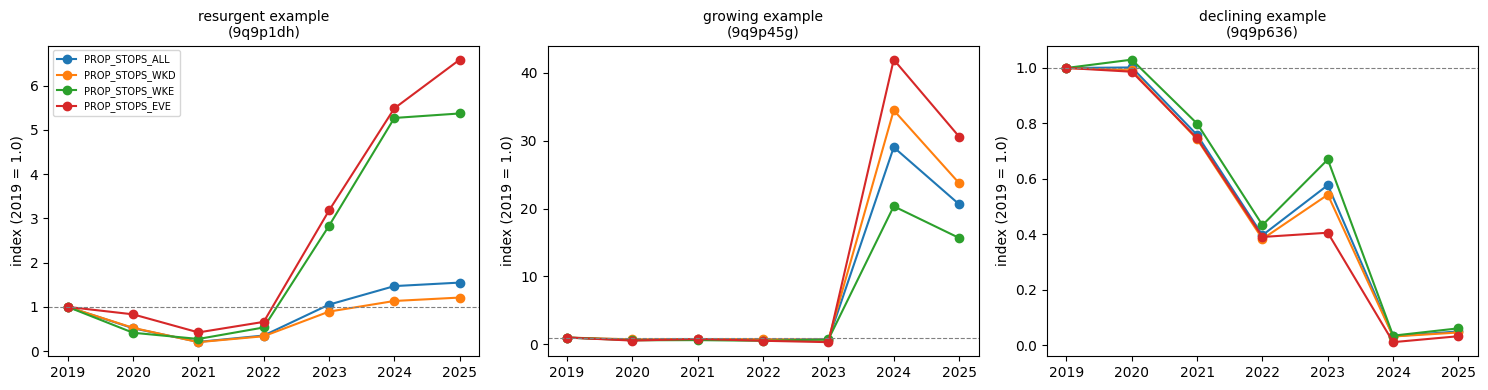

In [58]:
subset_cols = ["PROP_STOPS_ALL", "PROP_STOPS_WKD", "PROP_STOPS_WKE", "PROP_STOPS_EVE"]
fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 4), squeeze=False)
axes = axes[0]
for ax, (label, geohash7) in zip(axes, examples.items()):
    sub = act[act["GEOHASH7"] == geohash7].set_index("YEAR")[subset_cols].reindex(YEARS)
    # normalize each series to its own 2019 value so different-scale subsets are comparable on one plot
    normed = sub / sub.iloc[0]
    for col in subset_cols:
        ax.plot(normed.index, normed[col], marker="o", label=col)
    ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(f"{label}\n({geohash7})", fontsize=10)
    ax.set_ylabel("index (2019 = 1.0)")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

**Takeaway - Section 19.** For the examples checked here, the time-of-day subsets largely move together
with the overall `ALL` series rather than one subset (e.g. evenings) driving the whole trajectory on its
own - suggesting that, at least for these cells, recovery/growth/decline is fairly broad across the day
rather than concentrated in one time window. This is only a spot-check on a few geohashes; a fuller
weekday/weekend/evening breakdown across all corridors would be a natural extension once this framework
is paired with business data (Section 20), where "is recovery evening-driven" becomes directly relevant
to restaurant/bar/entertainment-sector interpretation.

## 20. Prepare for future business linkage

This notebook measures **activity resurgence** - a mobile-device signal of where people are physically
present and moving through Oakland. It does **not** measure **business resurgence** - openings,
closures, or shifts in business composition - which will require the longitudinal business dataset once
it is available (a natural companion to the `explore_axle_licenses.ipynb` cross-section already built).

The activity side of a future linked table would look like:

```text
geohash7
year

activity_share_stops        (PROP_STOPS_ALL)
activity_share_unique       (PROP_UNIQUE_ALL)

activity_change_1yr         (year-over-year absolute change in activity_share_stops)
activity_change_since_2019  (change_19_25-style long-term change)
pandemic_decline            (pandemic_low - 2019)
recovery_from_low           (endpoint - pandemic_low)
recent_momentum             (endpoint - prior year)

trajectory_class            (Section 10's typology)
resurgence_robustness        (Section 11's robustness_score)
```

A future business table, once longitudinal D&B/business-license data exist, could contribute:

```text
geohash7
year

n_businesses
n_openings
n_closures
net_business_change
sector_composition
```

joined on `(geohash7, year)`. That combination would let us distinguish, for example:

* **business growth + activity growth** - genuinely thriving areas
* **business decline + activity decline** - genuinely struggling areas
* **activity resurgence + business resurgence** - real recovery
* **activity recovery without business growth** - people returning to an area whose business base
  hasn't yet followed (or a business base dominated by non-retail/non-visible uses)
* **business growth without increased activity** - new businesses opening in areas that aren't (yet)
  drawing more foot traffic

We deliberately do **not** build this linkage in this notebook - only the activity side is ready.

## Key Findings and Next Steps

**On data comparability.** 2019, 2020, 2021, 2022, 2024, and 2025 are broadly comparable in Oakland
geohash-7 coverage and suppression rate. **2023 is a clear outlier** - roughly a third fewer geohash cells,
roughly double the raw-stops suppression rate, and more than triple the raw-unique-device suppression
rate of neighboring years - and the cells that drop out of the 2023
panel are disproportionately low-activity ones rather than a geographically clustered or random subset.
This is consistent with a coverage/reporting difference specific to 2023, not a real one-year activity
collapse, so any year-over-year comparison touching 2023 should be read cautiously, and none of this
notebook's pandemic-low or resurgence definitions rely on 2023.

**On stops vs. unique devices.** The two measures are strongly correlated in both level and change at the
geohash level - they broadly tell the same geographic story, which supports using stops as the primary
trajectory measure with unique devices as a genuine (not redundant) robustness check. A modest set of
geohashes disagree in the direction of change, worth flagging but not overinterpreting without more
context.

**On the 2019->2025 geography of activity.** A persistent core of high-activity cells anchors Oakland's
activity map in every year studied - the broad geography of where activity concentrates has not been
reshuffled. Growth, decline, and resurgence are geographically uneven: they concentrate in identifiable
pockets rather than spreading evenly citywide.

**On growth vs. resurgence vs. momentum.** These are genuinely different concepts and can diverge for the
same geohash: long-term growth driven entirely by pre-pandemic gains can coexist with flat or negative
recent (2024->2025) momentum, and vice versa. The trajectory classification in Section 10 treats these as
separate, jointly-considered dimensions rather than collapsing them into one score, and resurgence
specifically requires a *meaningful decline followed by meaningful recovery* - not just any positive
change - which keeps the resurgent categories appropriately rare.

**On the robustness of "resurgence."** A small core of geohashes is classified as some form of resurgence
under essentially every specification tested (alternate measure, endpoint year, pandemic-window
definition, and threshold strictness) - these are the ones worth the most confidence in a public-facing
product. A larger, borderline set is resurgent under only one or two specifications and should be
presented with that caveat, not as settled fact. The `robustness_score` is designed to travel with the
classification for exactly this reason.

**On corridors.** Centroid-based assignment of geohash-7 cells to the 20 available BID/Policy-Polygon
corridors is very restrictive - corridor polygons are narrow, street-level shapes while geohash-7 cells
are ~150m squares, so only a small handful of cells land inside any corridor boundary at all. The
resulting corridor-level trajectories should be read as thin, few-cell activity profiles for specific
named locations, not as statistically robust, comprehensive corridor measurements. Within-corridor
heterogeneity is correspondingly hard to assess meaningfully with so few contributing cells per corridor.

**On corridor-wide vs. localized resurgence.** Where corridor coverage does exist, the combined
aggregate-plus-composition classification (Section 18) demonstrates the intended distinction - a corridor
is only called "broadly resurgent" if a majority of its assigned cells individually support that
pattern, not merely because its one or two most active cells recovered.

**Key limitations for any public interpretation.** (1) 2023 requires an explicit caveat wherever it
appears. (2) Corridor-level results cover only a thin, uneven slice of Oakland due to the sparse
centroid-in-polygon overlap - they are not a citywide corridor census. (3) Unique-device counts must never
be summed across geohashes as a corridor "unique visitor" figure - only proportional shares are aggregated
here, and only for stops. (4) Nothing in this notebook supports a causal claim about *why* any area grew,
declined, or resurged. (5) "Resurgence" here means *mobile-activity* resurgence, not business resurgence -
the two must not be conflated until real business data are linked in.

**What becomes possible with longitudinal business data.** Once openings/closures/net-business-change
data exist at the geohash-year level (Section 20), this activity framework becomes directly joinable to
it - enabling the real question behind this whole project: which parts of Oakland are experiencing
activity growth *and* business growth together (real, durable resurgence), which show activity recovery
without a business response yet, and which show business growth in areas that haven't yet seen activity
follow.